# **CIFAR-100 Project - Transer Learning & Pretrained Models**

## **Overview**

CIFAR-100 is a labeled subset of the "80 Million Tiny Images" dataset, collected by Alex Krizhevsky, Vinod Nair, and Geoffrey Hinton at the University of Toronto. It's one of the standard benchmark datasets used in computer vision for evaluating image classification models, particularly useful for testing performance on a larger number of classes compared to its sibling dataset, CIFAR-10.

## Dataset Structure

| Property | Value |
|---|---|
| **Total images** | 60,000 |
| **Training set** | 50,000 images |
| **Test set** | 10,000 images |
| **Image size** | 32 × 32 pixels |
| **Color channels** | 3 (RGB) |
| **Number of classes** | 100 |
| **Images per class** | 600 (500 train + 100 test) |
| **File size** | ~161 MB (Python pickle format) |

## **Example Superclass Groupings**

| **Superclass** | **Fine Classes** |
|---|---|
| Aquatic mammals | beaver, dolphin, otter, seal, whale |
| Flowers | orchid, poppy, rose, sunflower, tulip |
| Vehicles 1 | bicycle, bus, motorcycle, pickup truck, train |
| Trees | maple, oak, palm, pine, willow |
| Large carnivores | bear, leopard, lion, tiger, wolf |

## **Data Format**

Each image is stored as a flat array of 3,072 values (32×32×3), typically reshaped to `(32, 32, 3)` for RGB image loading.

## **Key Characteristics & Challenges**

- **Low resolution (32×32)** makes fine-grained distinctions harder than in higher-resolution datasets — small objects, texture details, and subtle inter-class differences (e.g. "maple" vs "oak" tree) are genuinely difficult even for humans at this resolution.
- **Only 500 training images per class** — significantly less data per class than CIFAR-10 (which has 5,000/class), making CIFAR-100 more prone to overfitting and a better test of a model's generalization ability.
- **Higher inherent difficulty** — with more classes, less data per class, and finer-grained distinctions, state-of-the-art accuracy on CIFAR-100 is typically lower than on CIFAR-10 for comparable architectures (e.g. a ResNet that gets ~95%+ on CIFAR-10 might get ~75-80% on CIFAR-100).
- **No official validation split** — most researchers carve out a validation set from the training 50,000 themselves (commonly a 45k/5k split).


# **Libraries**

In [1]:
import os
import time
import random
import shutil
import pathlib
import numpy as np
import pandas as pd
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.utils import to_categorical

import warnings

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.20.0


# **Data Loading**

In [2]:
import kagglehub

path = kagglehub.dataset_download("melikechan/cifar100")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/melikechan/cifar100


In [3]:
data_path = pathlib.Path("/kaggle/input/datasets/melikechan/cifar100/cifar100")

In [4]:
train_dir = os.path.join(data_path, "train")
test_dir = os.path.join(data_path, "test")

In [5]:
# folder_to_zip = "/kaggle/input/datasets/melikechan/cifar100/cifar100/train"
# output_zip_name = "cifar100_train"

# shutil.make_archive(output_zip_name, 'zip', folder_to_zip)

# folder_to_zip = "/kaggle/input/datasets/melikechan/cifar100/cifar100/test"
# output_zip_name = "cifar100_test"

# shutil.make_archive(output_zip_name, 'zip', folder_to_zip)

# **Classes**

In [6]:
cifar100_fine_labels = [
    "apple", "aquarium_fish", "baby", "bear", "beaver", "bed", "bee", "beetle", "bicycle", "bottle",
    "bowl", "boy", "bridge", "bus", "butterfly", "camel", "can", "castle", "caterpillar", "cattle",
    "chair", "chimpanzee", "clock", "cloud", "cockroach", "couch", "crab", "crocodile", "cup", "dinosaur",
    "dolphin", "elephant", "flatfish", "forest", "fox", "girl", "hamster", "house", "kangaroo", "keyboard",
    "lamp", "lawn_mower", "leopard", "lion", "lizard", "lobster", "man", "maple_tree", "motorcycle", "mountain",
    "mouse", "mushroom", "oak_tree", "orange", "orchid", "otter", "palm_tree", "pear", "pickup_truck", "pine_tree",
    "plain", "plate", "poppy", "porcupine", "possum", "rabbit", "raccoon", "ray", "road", "rocket",
    "rose", "sea", "seal", "shark", "shrew", "skunk", "skyscraper", "snail", "snake", "spider",
    "squirrel", "streetcar", "sunflower", "sweet_pepper", "table", "tank", "telephone", "television", "tiger", "tractor",
    "train", "trout", "tulip", "turtle", "wardrobe", "whale", "willow_tree", "wolf", "woman", "worm"
]
print(f"{len(cifar100_fine_labels)} CIFAR-100 classes")

100 CIFAR-100 classes


In [7]:
assert len(cifar100_fine_labels) == len(set(cifar100_fine_labels)) == 100, "Duplicate or missing class name!"

# **Analysis & Preprocessing**

In [8]:
# folder_to_zip = "cifar100_test"
# output_zip_name = "cifar100_test"

# shutil.make_archive(output_zip_name, 'zip', folder_to_zip)

train_dir_path = Path(train_dir)
test_dir_path = Path(test_dir)

Check Channels & Format & Modes

In [9]:
def channel_stats(data_dir: Path):
    channel_sum = np.zeros(3, dtype=np.float64)
    channel_sum_sq = np.zeros(3, dtype=np.float64)
    total_pixels = 0

    for class_name in os.listdir(data_dir):
        class_dir = data_dir / class_name

        for img_name in os.listdir(class_dir):
            img_path = class_dir / img_name

            with Image.open(img_path) as img:
                img_arr = np.array(img.convert("RGB"), dtype=np.float32) / 255.0  # scale to 0-1

            channel_sum += img_arr.sum(axis=(0, 1))
            channel_sum_sq += (img_arr ** 2).sum(axis=(0, 1))
            total_pixels += img_arr.shape[0] * img_arr.shape[1]

    mean = channel_sum / total_pixels
    std = np.sqrt(channel_sum_sq / total_pixels - mean ** 2)

    print(f"Per-channel mean (RGB): {mean}")
    print(f"Per-channel std  (RGB): {std}\n")
    return mean, std


train_mean, train_std = channel_stats(train_dir_path)
print(f"Training Mean : {train_mean}, Training STD : {train_std}\n\n")

test_mean, test_std = channel_stats(test_dir_path)
print(f"Testing Mean : {test_mean}, Testing STD : {test_std}")

Per-channel mean (RGB): [0.5070749  0.48654877 0.44091765]
Per-channel std  (RGB): [0.26733459 0.25643848 0.27615065]

Training Mean : [0.5070749  0.48654877 0.44091765], Training STD : [0.26733459 0.25643848 0.27615065]


Per-channel mean (RGB): [0.50879616 0.48739292 0.44194202]
Per-channel std  (RGB): [0.26825188 0.25736374 0.27709594]

Testing Mean : [0.50879616 0.48739292 0.44194202], Testing STD : [0.26825188 0.25736374 0.27709594]


In [10]:
def check_formats_and_modes(data_dir: Path) -> tuple[set[str], set[str]]:
    img_formats = set()
    color_modes = set()

    for class_name in os.listdir(data_dir):
        class_dir = data_dir / class_name

        for img_name in os.listdir(class_dir):
            img_path = class_dir / img_name

            img_formats.add(img_path.suffix)
            color_modes.add(Image.open(img_path).mode)

    return img_formats, color_modes

img_formats = set()
color_modes = set()
for dir in [train_dir_path, test_dir_path]:
    formats, modes = check_formats_and_modes(dir)
    img_formats |= formats
    color_modes |= modes

print(f"Image Formats: {img_formats}")
print(f"Color Modes: {color_modes}")

Image Formats: {'.png'}
Color Modes: {'RGB'}


Check Images' Sizes

In [11]:
def check_image_sizes(data_dir, num_samples=50):
    sizes = []

    for cls in os.listdir(data_dir):
        cls_path = os.path.join(data_dir, cls)

        images = os.listdir(cls_path)
        sample_images = random.sample(images, min(num_samples, len(images)))

        for img_name in sample_images:
            img_path = os.path.join(cls_path, img_name)

            try:
                with Image.open(img_path) as img:
                    sizes.append(img.size)
            except:
                pass
    return sizes

sizes = check_image_sizes(train_dir_path)
unique_sizes = set(sizes)

print("Unique image sizes found:", unique_sizes)

Unique image sizes found: {(32, 32)}


Check Duplication

In [12]:
def find_duplicates(data_dir: Path):
    all_flat = []

    for class_name in os.listdir(data_dir):
        class_dir = data_dir / class_name

        for img_name in os.listdir(class_dir):
            img_path = class_dir / img_name

            with Image.open(img_path) as img:
                img_arr = np.array(img.convert("RGB"))

            all_flat.append(img_arr.flatten())

    all_flat = np.array(all_flat)
    _, inverse, counts = np.unique(all_flat, axis=0, return_inverse=True, return_counts=True)
    dup_count = (counts > 1).sum()

    print(f"Number of duplicate image groups: {dup_count}")
    return dup_count


train_dup_count = find_duplicates(train_dir_path)
print(f"Training Duplicates Images Count : {train_dup_count}")

test_dup_count = find_duplicates(test_dir_path)
print(f"Testing Duplicates Images Count : {test_dup_count}")

Number of duplicate image groups: 14
Training Duplicates Images Count : 14
Number of duplicate image groups: 2
Testing Duplicates Images Count : 2


In [13]:
def check_cross_split_duplicates(train_dir: Path, test_dir: Path):
    def load_flattened(data_dir):
        flat_images = []
        for class_name in os.listdir(data_dir):
            class_dir = data_dir / class_name
            for img_name in os.listdir(class_dir):
                img_path = class_dir / img_name
                with Image.open(img_path) as img:
                    img_arr = np.array(img.convert("RGB"))
                flat_images.append(img_arr.flatten())
        return np.array(flat_images)

    train_flat = load_flattened(train_dir)
    test_flat = load_flattened(test_dir)

    combined = np.concatenate([train_flat, test_flat], axis=0)
    split_labels = np.array(['train'] * len(train_flat) + ['test'] * len(test_flat))

    _, inverse, counts = np.unique(combined, axis=0, return_inverse=True, return_counts=True)
    dup_group_ids = np.where(counts > 1)[0]

    leaks = []
    for group_id in dup_group_ids:
        idxs = np.where(inverse == group_id)[0]
        splits_in_group = set(split_labels[idxs])
        if len(splits_in_group) > 1:
            leaks.append(idxs)

    print(f"Cross-split duplicate groups (train/test leakage): {len(leaks)}")
    return leaks


leaks = check_cross_split_duplicates(train_dir_path, test_dir_path)

Cross-split duplicate groups (train/test leakage): 10


Check Corruption

In [14]:
def check_corrupted_arrays(data_dir: Path) -> int:
    n_bad = 0

    for class_name in os.listdir(data_dir):
        class_dir = data_dir / class_name

        for img_name in os.listdir(class_dir):
            img_path = class_dir / img_name

            try:
                with Image.open(img_path) as img:
                    img_arr = np.array(img.convert("RGB"))
            except Exception:
                n_bad += 1
                continue

            if img_arr.sum() == 0:
                n_bad += 1

    print(f"Corrupted/empty images: {n_bad}")
    return n_bad


n_bad_train = check_corrupted_arrays(train_dir_path)
n_bad_test = check_corrupted_arrays(test_dir_path)

Corrupted/empty images: 0
Corrupted/empty images: 0


Check Balancing

In [15]:
def count_images_per_class(data_dir: Path, label_names: list[str]) -> dict:
    counts = {}
    for class_name in label_names:
        class_dir = data_dir / class_name
        if class_dir.exists():
            counts[class_name] = len(os.listdir(class_dir))
        else:
            counts[class_name] = 0
    return counts

In [16]:
train_counts = count_images_per_class(train_dir_path, cifar100_fine_labels)
print("Training set distribution:", train_counts)

Training set distribution: {'apple': 500, 'aquarium_fish': 500, 'baby': 500, 'bear': 500, 'beaver': 500, 'bed': 500, 'bee': 500, 'beetle': 500, 'bicycle': 500, 'bottle': 500, 'bowl': 500, 'boy': 500, 'bridge': 500, 'bus': 500, 'butterfly': 500, 'camel': 500, 'can': 500, 'castle': 500, 'caterpillar': 500, 'cattle': 500, 'chair': 500, 'chimpanzee': 500, 'clock': 500, 'cloud': 500, 'cockroach': 500, 'couch': 500, 'crab': 500, 'crocodile': 500, 'cup': 500, 'dinosaur': 500, 'dolphin': 500, 'elephant': 500, 'flatfish': 500, 'forest': 500, 'fox': 500, 'girl': 500, 'hamster': 500, 'house': 500, 'kangaroo': 500, 'keyboard': 500, 'lamp': 500, 'lawn_mower': 500, 'leopard': 500, 'lion': 500, 'lizard': 500, 'lobster': 500, 'man': 500, 'maple_tree': 500, 'motorcycle': 500, 'mountain': 500, 'mouse': 500, 'mushroom': 500, 'oak_tree': 500, 'orange': 500, 'orchid': 500, 'otter': 500, 'palm_tree': 500, 'pear': 500, 'pickup_truck': 500, 'pine_tree': 500, 'plain': 500, 'plate': 500, 'poppy': 500, 'porcupin

In [17]:
test_counts = count_images_per_class(test_dir_path, cifar100_fine_labels)
print("Testing set distribution:", test_counts)

Testing set distribution: {'apple': 100, 'aquarium_fish': 100, 'baby': 100, 'bear': 100, 'beaver': 100, 'bed': 100, 'bee': 100, 'beetle': 100, 'bicycle': 100, 'bottle': 100, 'bowl': 100, 'boy': 100, 'bridge': 100, 'bus': 100, 'butterfly': 100, 'camel': 100, 'can': 100, 'castle': 100, 'caterpillar': 100, 'cattle': 100, 'chair': 100, 'chimpanzee': 100, 'clock': 100, 'cloud': 100, 'cockroach': 100, 'couch': 100, 'crab': 100, 'crocodile': 100, 'cup': 100, 'dinosaur': 100, 'dolphin': 100, 'elephant': 100, 'flatfish': 100, 'forest': 100, 'fox': 100, 'girl': 100, 'hamster': 100, 'house': 100, 'kangaroo': 100, 'keyboard': 100, 'lamp': 100, 'lawn_mower': 100, 'leopard': 100, 'lion': 100, 'lizard': 100, 'lobster': 100, 'man': 100, 'maple_tree': 100, 'motorcycle': 100, 'mountain': 100, 'mouse': 100, 'mushroom': 100, 'oak_tree': 100, 'orange': 100, 'orchid': 100, 'otter': 100, 'palm_tree': 100, 'pear': 100, 'pickup_truck': 100, 'pine_tree': 100, 'plain': 100, 'plate': 100, 'poppy': 100, 'porcupine

In [18]:
def check_class_balance(counts: dict):
    vals = list(counts.values())
    print(f"Min class count: {min(vals)}, Max class count: {max(vals)}")
    print(f"Imbalance ratio (max/min): {max(vals)/min(vals):.2f}\n")

check_class_balance(train_counts)
check_class_balance(test_counts)

Min class count: 500, Max class count: 500
Imbalance ratio (max/min): 1.00

Min class count: 100, Max class count: 100
Imbalance ratio (max/min): 1.00



Plot Data Distribution

/tmp/ipykernel_58/3418691279.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(labels, rotation=90)
/tmp/ipykernel_58/3418691279.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(labels, rotation=90)
/tmp/ipykernel_58/3418691279.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(labels, rotation=90)
/tmp/ipykernel_58/3418691279.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(labels, rotation=90)


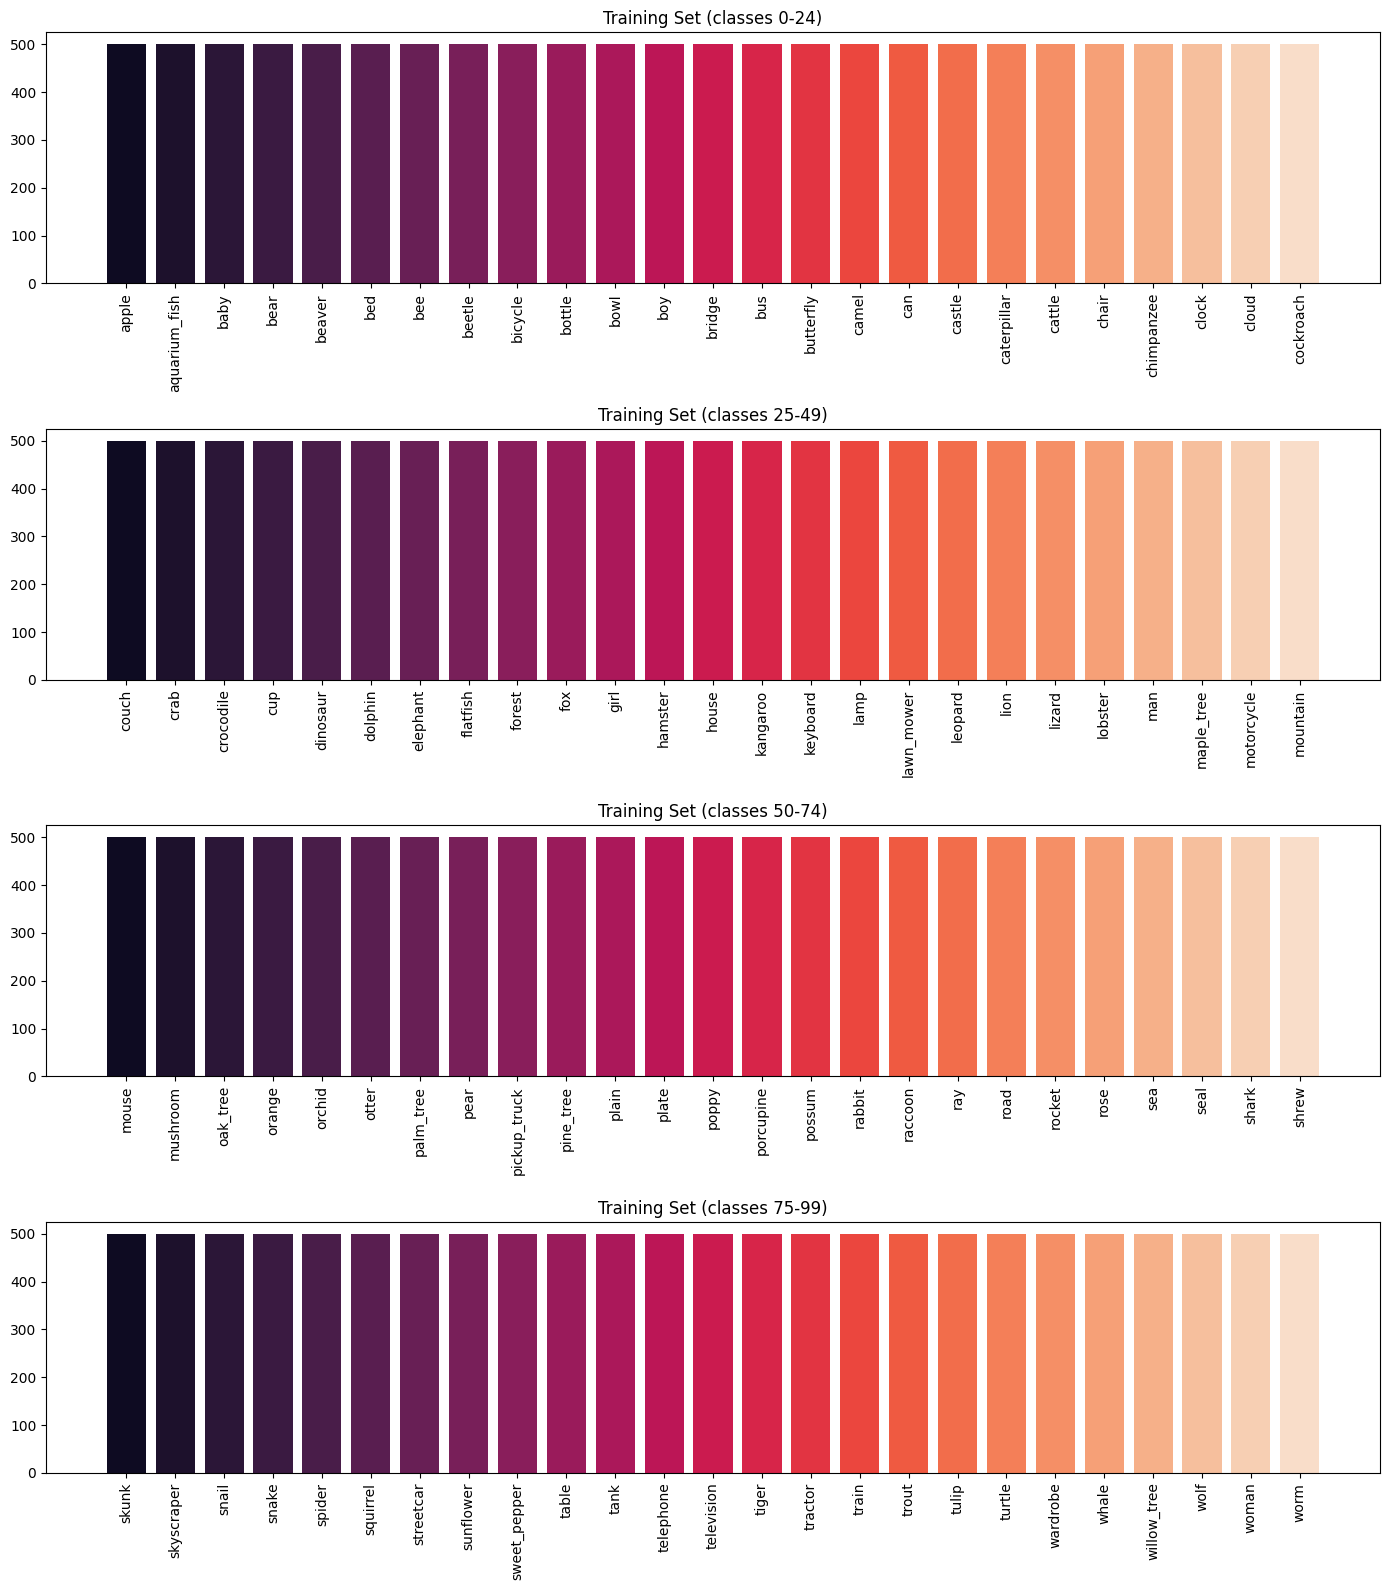

In [19]:
def plot_in_chunks(counts: dict, chunk_size=25, title="Class Distribution"):
    items = sorted(counts.items())
    n_chunks = int(np.ceil(len(items) / chunk_size))

    fig, axes = plt.subplots(n_chunks, 1, figsize=(14, 4 * n_chunks))
    if n_chunks == 1:
        axes = [axes]

    for i in range(n_chunks):
        chunk = items[i*chunk_size:(i+1)*chunk_size]
        labels, values = zip(*chunk)
        axes[i].bar(labels, values, color=sns.color_palette("rocket", len(labels)))
        axes[i].set_xticklabels(labels, rotation=90)
        axes[i].set_title(f"{title} (classes {i*chunk_size}-{i*chunk_size+len(chunk)-1})")

    plt.tight_layout()
    plt.show()

plot_in_chunks(train_counts, chunk_size=25, title="Training Set")

/tmp/ipykernel_58/3418691279.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(labels, rotation=90)
/tmp/ipykernel_58/3418691279.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(labels, rotation=90)
/tmp/ipykernel_58/3418691279.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(labels, rotation=90)
/tmp/ipykernel_58/3418691279.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(labels, rotation=90)


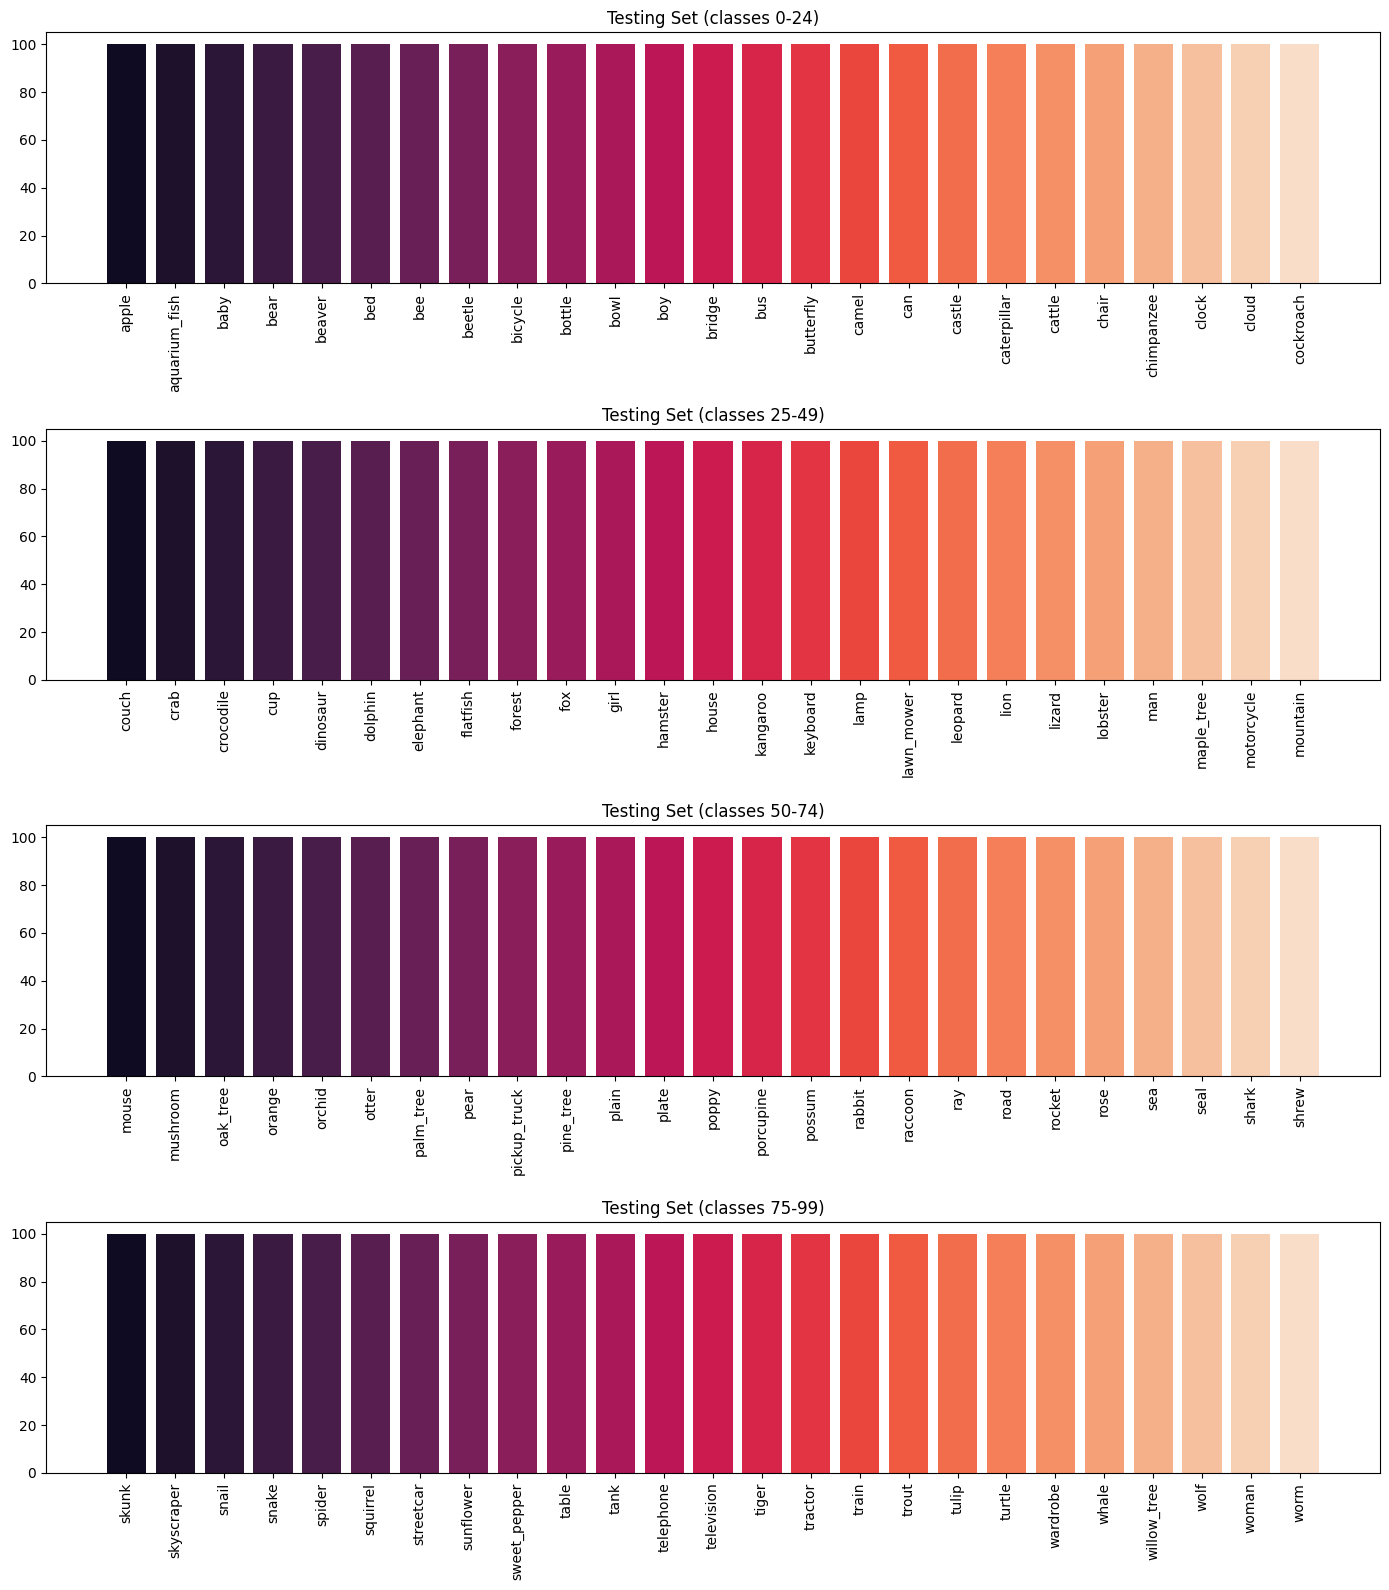

In [20]:
plot_in_chunks(test_counts, chunk_size=25, title="Testing Set")

show some samples of data

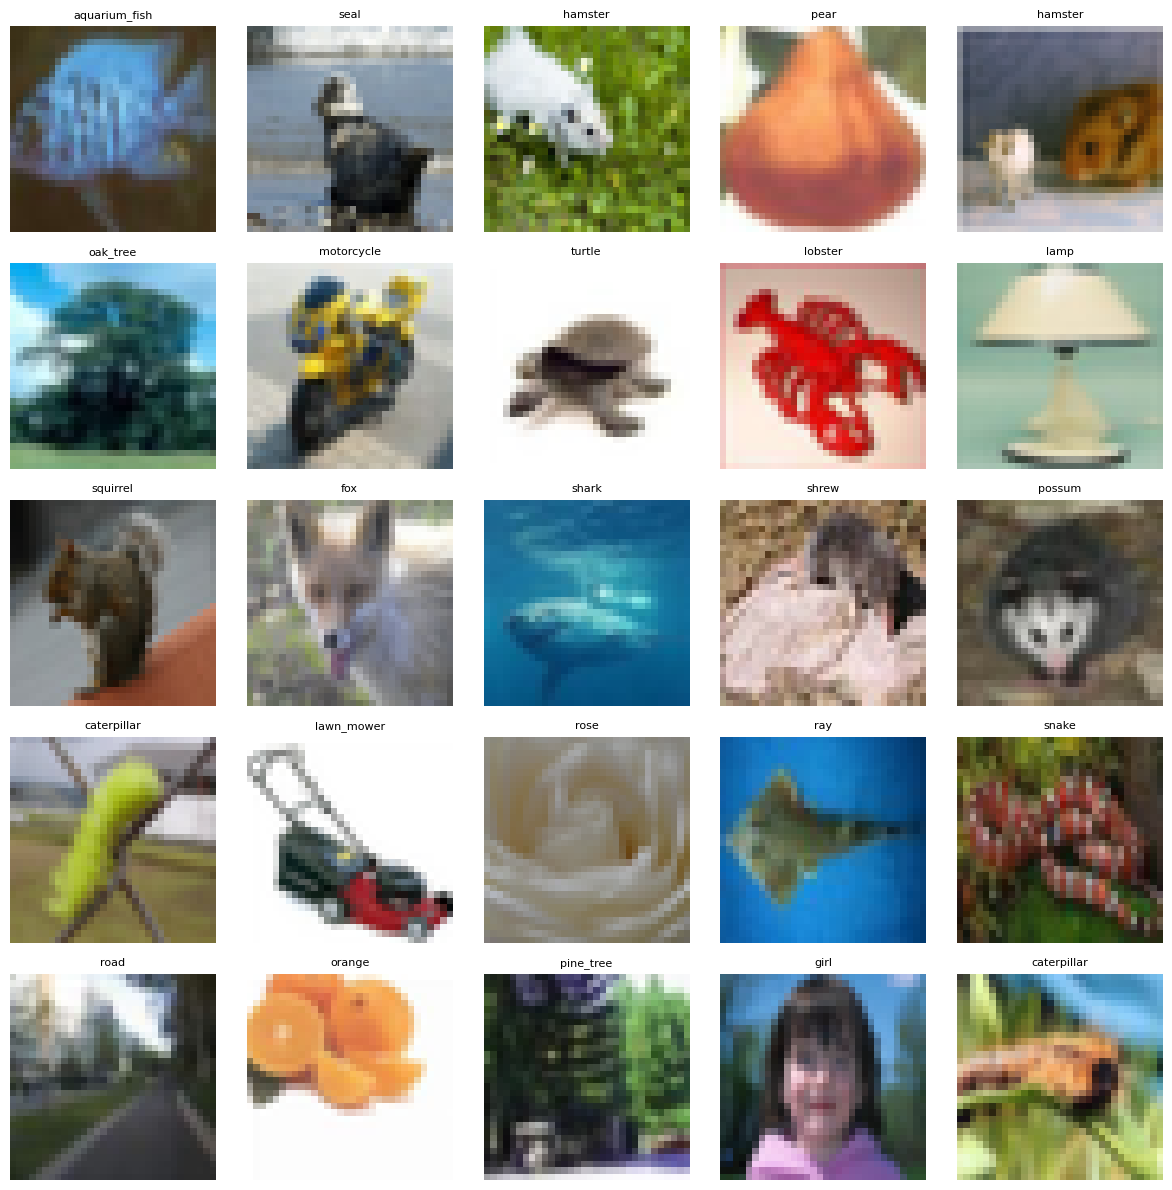

In [21]:
def show_sample_grid(data_dir: Path, label_names: list[str], n=25):
    # build a flat list of (image_path, class_name) across all classes
    all_images = []
    for class_name in os.listdir(data_dir):
        class_dir = data_dir / class_name
        for img_name in os.listdir(class_dir):
            all_images.append((class_dir / img_name, class_name))

    sample = random.sample(all_images, n)

    cols = 5
    rows = (n + cols - 1) // cols
    plt.figure(figsize=(12, 2.4 * rows))

    for i, (img_path, class_name) in enumerate(sample):
        with Image.open(img_path) as img:
            plt.subplot(rows, cols, i + 1)
            plt.imshow(img)
            plt.title(class_name, fontsize=8)
            plt.axis('off')

    plt.tight_layout()
    plt.show()


show_sample_grid(train_dir_path, cifar100_fine_labels)

# **Split the data**

In [22]:
IMG_SIZE = (128, 128)      
BATCH_SIZE = 32
SEED = 42
NUM_CLASSES = 100

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 50000 files belonging to 100 classes.


I0000 00:00:1788432931.440051      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788432931.442754      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 10000 files belonging to 100 classes.


# **Some Functions**

In [23]:
def build_model(backbone_model, NUM_CLASSES):
    inputs = layers.Input(shape = backbone_model.input_shape[1:])
    x = layers.Rescaling(1./127.5, offset=-1)(inputs)
    # x = layers.RandomFlip("horizontal")(x)
    # x = layers.RandomRotation(0.2)(x)
    # x = layers.RandomZoom(0.1)(x)
    x = backbone_model(x, training = False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(NUM_CLASSES, activation = 'softmax')(x)
    
    return models.Model(inputs, outputs)

In [24]:
def train_model(model, text, train_ds, val_ds,
                BATCH_SIZE, patience = 2, EPOCHS = 5, cb = False):

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = patience, restore_best_weights = True),
        tf.keras.callbacks.LearningRateScheduler(lambda epoch, lr: lr * 0.95),
        tf.keras.callbacks.ModelCheckpoint(f"{text}_with_callbacks.h5", save_best_only=True, monitor='val_loss')
    ]

    modelcheckpoint = tf.keras.callbacks.ModelCheckpoint(f"{text}_without_callbacks.h5",
                                                         save_best_only=True, monitor='val_loss')



    start_time = time.time()
    
    if cb:
        history = model.fit(
            train_ds, validation_data=val_ds,
            epochs=EPOCHS,
            batch_size = BATCH_SIZE,
            callbacks = modelcheckpoint
        )
        
    else:
        history = model.fit(
            train_ds, validation_data=val_ds,
            epochs=EPOCHS,
            batch_size = BATCH_SIZE,
            callbacks = callbacks
        )
        
    training_time = time.time() - start_time
    
    print(f"{text} Training Time: {training_time:.2f} seconds")
    print(f"{text} Best Val Accuracy: {max(history.history['val_accuracy']):.4f}")

    return history, training_time

In [25]:
def plot_loss_accuracy_comparison (history):
    loss = history.history['loss']
    loss_val = history.history['val_loss']
    accuracy = history.history['accuracy']
    accuracy_val = history.history['val_accuracy']

    plt.figure(figsize = (12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(loss, label = 'Training Loss')
    plt.plot(loss_val, label = 'Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(accuracy, label = 'Training Accuracy')
    plt.plot(accuracy_val, label = 'Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    plt.show()

In [26]:
def confusion_matrix_and_classification_report(model, dataset, title="Confusion Matrix & Classification Report", class_names=None, display_confusion_for_worst_n_classes=10, plot_full_cm=False):
    y_true, y_pred, y_probs = [], [], []

    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        preds = np.argmax(probs, axis=1)
        labels = np.argmax(labels.numpy(), axis=1) if len(labels.shape) > 1 else labels.numpy()

        y_true.extend(labels)
        y_pred.extend(preds)
        y_probs.extend(probs)

    y_true, y_pred, y_probs = np.array(y_true), np.array(y_pred), np.array(y_probs)

    all_labels = list(range(len(class_names)))

    print(f"\n{title}\n" + "-" * len(title))
    report_str = classification_report(y_true, y_pred, labels=all_labels, target_names=class_names, zero_division=0)
    print(report_str)

    if plot_full_cm:

        cm_full = confusion_matrix(y_true, y_pred, labels=all_labels)
        plt.figure(figsize=(25, 25))
        sns.heatmap(cm_full, annot=False, fmt='d', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names)
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title(f'{title} (All Classes - Crowded)')
        plt.tight_layout()
        plt.show()

    elif display_confusion_for_worst_n_classes > 0:

        f1_scores = f1_score(y_true, y_pred, labels=all_labels, average=None, zero_division=0)
        worst_classes_indices = np.argsort(f1_scores)[:display_confusion_for_worst_n_classes]

        filtered_y_true = []
        filtered_y_pred = []
        filtered_class_names = [class_names[i] for i in worst_classes_indices]

        for i in range(len(y_true)):
            if y_true[i] in worst_classes_indices or y_pred[i] in worst_classes_indices:
                filtered_y_true.append(y_true[i])
                filtered_y_pred.append(y_pred[i])

        old_to_new_index_map = {old_idx: new_idx for new_idx, old_idx in enumerate(worst_classes_indices)}
        remapped_y_true = [old_to_new_index_map.get(label, -1) for label in filtered_y_true]
        remapped_y_pred = [old_to_new_index_map.get(label, -1) for label in filtered_y_pred]

        final_remapped_y_true = [t for t in remapped_y_true if t != -1]
        final_remapped_y_pred = [p for i, p in enumerate(remapped_y_pred) if remapped_y_true[i] != -1]

        if not final_remapped_y_true:
            print(f"No examples found for the worst {display_confusion_for_worst_n_classes} classes to display a confusion matrix.")
        else:
            cm_filtered = confusion_matrix(final_remapped_y_true, final_remapped_y_pred, labels=list(range(len(filtered_class_names))))

            plt.figure(figsize=(display_confusion_for_worst_n_classes * 1.2, display_confusion_for_worst_n_classes * 1.2))
            sns.heatmap(cm_filtered, annot=True, fmt='d', cmap='Blues',
                        xticklabels=filtered_class_names, yticklabels=filtered_class_names)
            plt.xlabel('Predicted Label')
            plt.ylabel('True Label')
            plt.title(f'{title} (Worst {display_confusion_for_worst_n_classes} Classes by F1-Score)')
            plt.tight_layout()
            plt.show()

In [27]:
def show_misclassified_examples_standalone(model, test_ds, class_names, n=9):
    all_images = []
    all_true = []
    all_pred = []

    for batch_images, batch_labels in test_ds:
        batch_probs = model.predict(batch_images, verbose=0)
        batch_pred = np.argmax(batch_probs, axis=1)

        batch_labels_np = batch_labels.numpy()
        if len(batch_labels_np.shape) > 1 and batch_labels_np.shape[1] > 1:
            batch_true = np.argmax(batch_labels_np, axis=1)
        else:
            batch_true = batch_labels_np.flatten()

        all_images.append(batch_images.numpy())
        all_true.append(batch_true)
        all_pred.append(batch_pred)

    all_images = np.concatenate(all_images, axis=0)
    all_true = np.concatenate(all_true, axis=0)
    all_pred = np.concatenate(all_pred, axis=0)

    mismatches = [i for i, (t, p) in enumerate(zip(all_true, all_pred)) if t != p]
    display_mismatches = mismatches[:n]

    print(f"Found {len(mismatches)} misclassified examples out of {len(all_true)} total")

    plt.figure(figsize=(12, 12))
    for i, idx in enumerate(display_mismatches):
        plt.subplot(3, 3, i + 1)

        img = all_images[idx]
        if img.dtype != np.uint8:
            img = np.clip(img, 0, 255).astype(np.uint8) if img.max() > 1.5 else np.clip(img, 0, 1)

        plt.imshow(img)
        plt.title(f"True: {class_names[all_true[idx]]}\nPred: {class_names[all_pred[idx]]}", fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# **Main Task : Fine-Tuning & Model Training & Comparison**

## **Phase 1: Feature Extraction**

### **Model A: ResNet50V2 with Frozen Backbone**

In [28]:
base_model_resnet = tf.keras.applications.ResNet50V2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [30]:
base_model_resnet.trainable = False

model_resnet = build_model(base_model_resnet, NUM_CLASSES)

model_resnet.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 4, 4, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       204,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,769,700 (90.67 MB)

 Trainable params: 204,900 (800.39 KB)

 Non-trainable params: 23,564,800 (89.89 MB)

In [31]:
history_resnet, train_time_resnet = train_model(model_resnet, "ResNet50V2", train_ds, test_ds, BATCH_SIZE)

Epoch 1/5
   5/1563 ━━━━━━━━━━━━━━━━━━━━ 53s 35ms/step - accuracy: 0.0121 - loss: 6.1514     

I0000 00:00:1788433866.432592     140 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4176 - loss: 2.5991

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 40ms/step - accuracy: 0.5040 - loss: 2.0904 - val_accuracy: 0.5858 - val_loss: 1.6658 - learning_rate: 9.5000e-04
Epoch 2/5
1562/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6244 - loss: 1.4199

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 50s 32ms/step - accuracy: 0.6253 - loss: 1.4226 - val_accuracy: 0.5995 - val_loss: 1.6514 - learning_rate: 9.0250e-04
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 48s 31ms/step - accuracy: 0.6671 - loss: 1.2156 - val_accuracy: 0.5992 - val_loss: 1.6937 - learning_rate: 8.5737e-04
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 48s 31ms/step - accuracy: 0.6936 - loss: 1.0829 - val_accuracy: 0.6054 - val_loss: 1.7258 - learning_rate: 8.1451e-04
ResNet50V2 Training Time: 221.81 seconds
ResNet50V2 Best Val Accuracy: 0.6054


#### **Results of ResNet50**

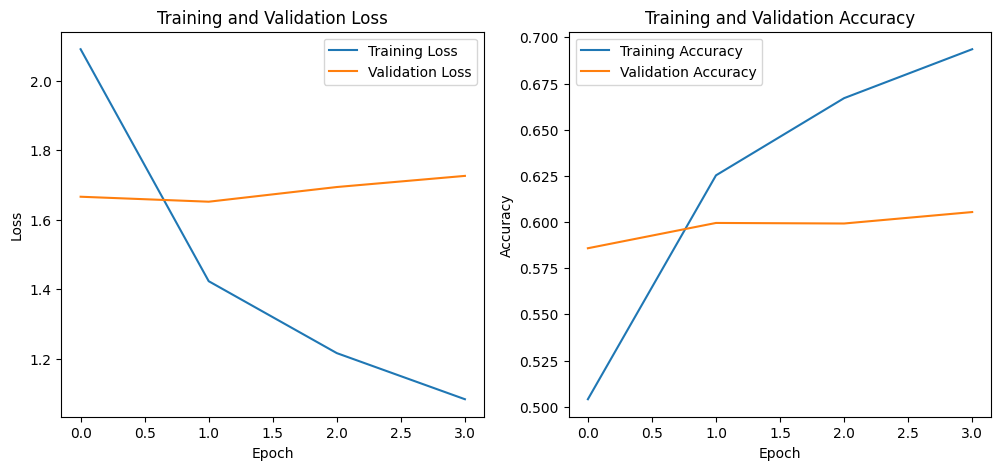

In [32]:
plot_loss_accuracy_comparison(history_resnet)

Displaying Confusion Matrix for worst 30 classes & classification report


Confusion Matrix
----------------
               precision    recall  f1-score   support

        apple       0.85      0.77      0.81       100
aquarium_fish       0.69      0.74      0.71       100
         baby       0.42      0.50      0.46       100
         bear       0.46      0.57      0.51       100
       beaver       0.39      0.60      0.47       100
          bed       0.53      0.77      0.63       100
          bee       0.52      0.65      0.58       100
       beetle       0.60      0.61      0.60       100
      bicycle       0.62      0.79      0.69       100
       bottle       0.83      0.79      0.81       100
         bowl       0.69      0.37      0.48       100
          boy       0.37      0.52      0.43       100
       bridge       0.73      0.61      0.67       100
          bus       0.60      0.59      0.59       100
    butterfly       0.62      0.56      0.59       100
        camel       0.83      0.50      0.62       100
          can       0.73     

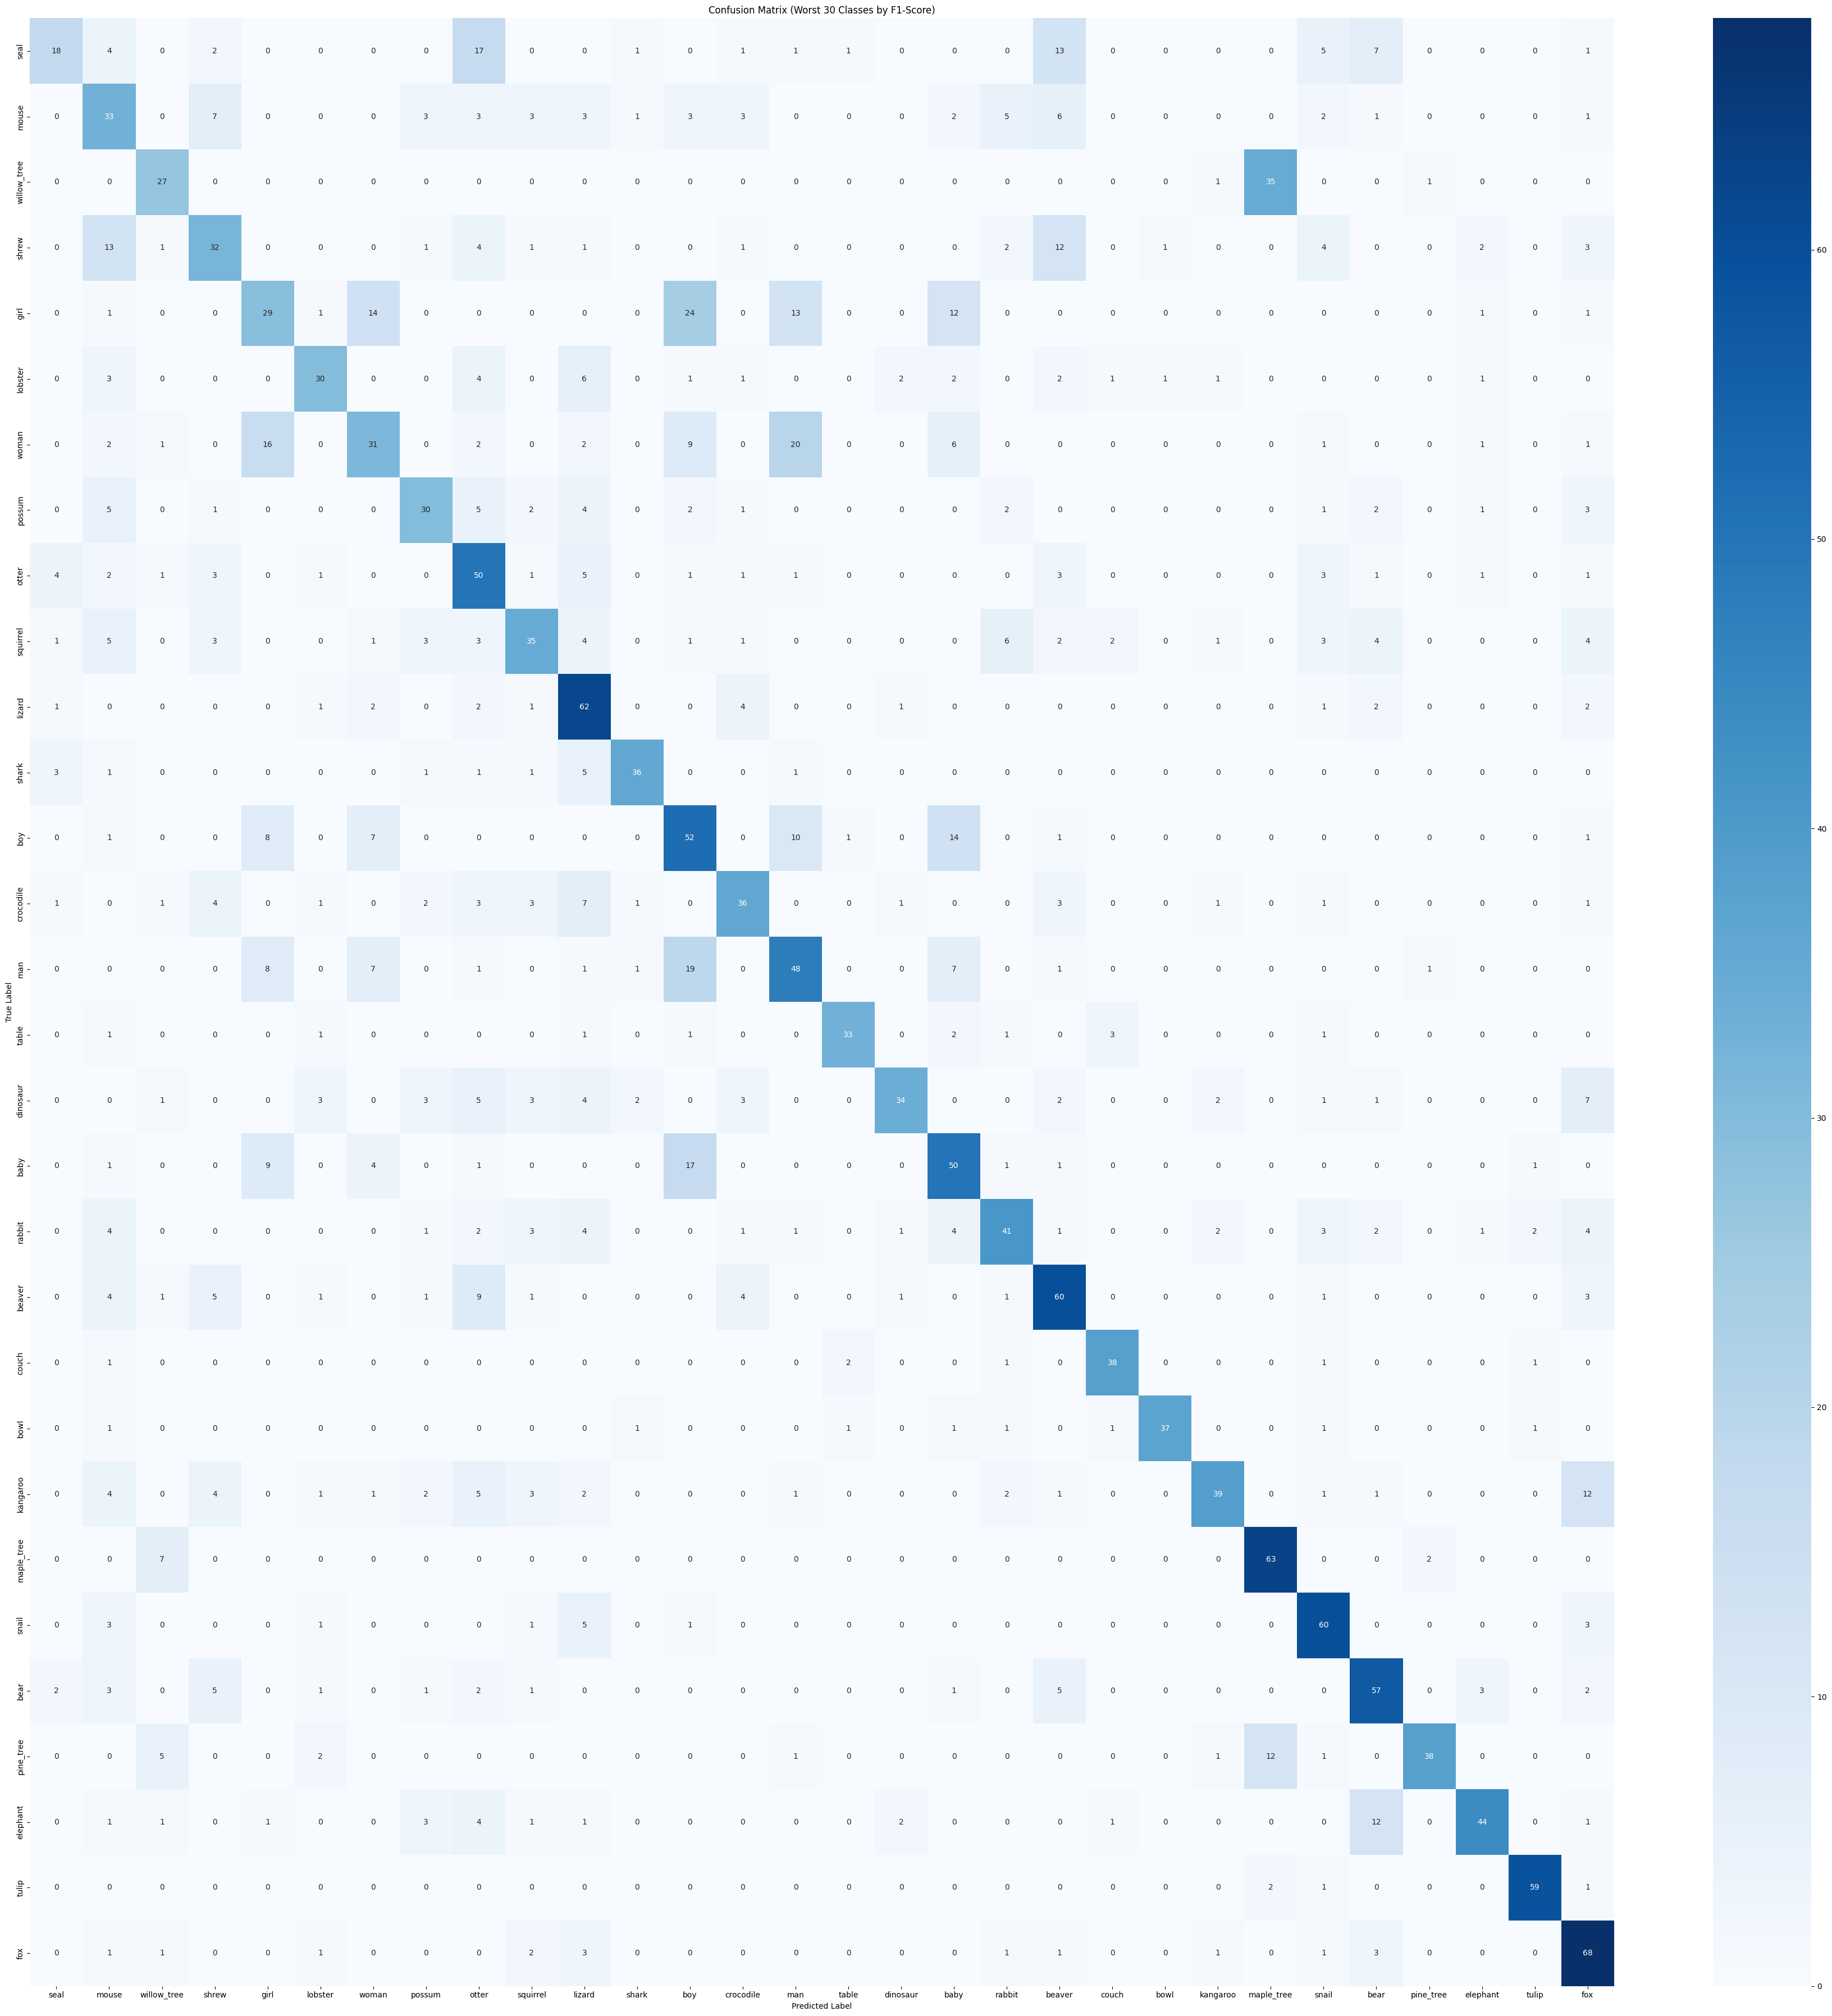

In [33]:
confusion_matrix_and_classification_report(model_resnet, test_ds, title="Confusion Matrix",
                                           class_names=cifar100_fine_labels, display_confusion_for_worst_n_classes=30)

Displaying Misclassified Examples

Found 4005 misclassified examples out of 10000 total


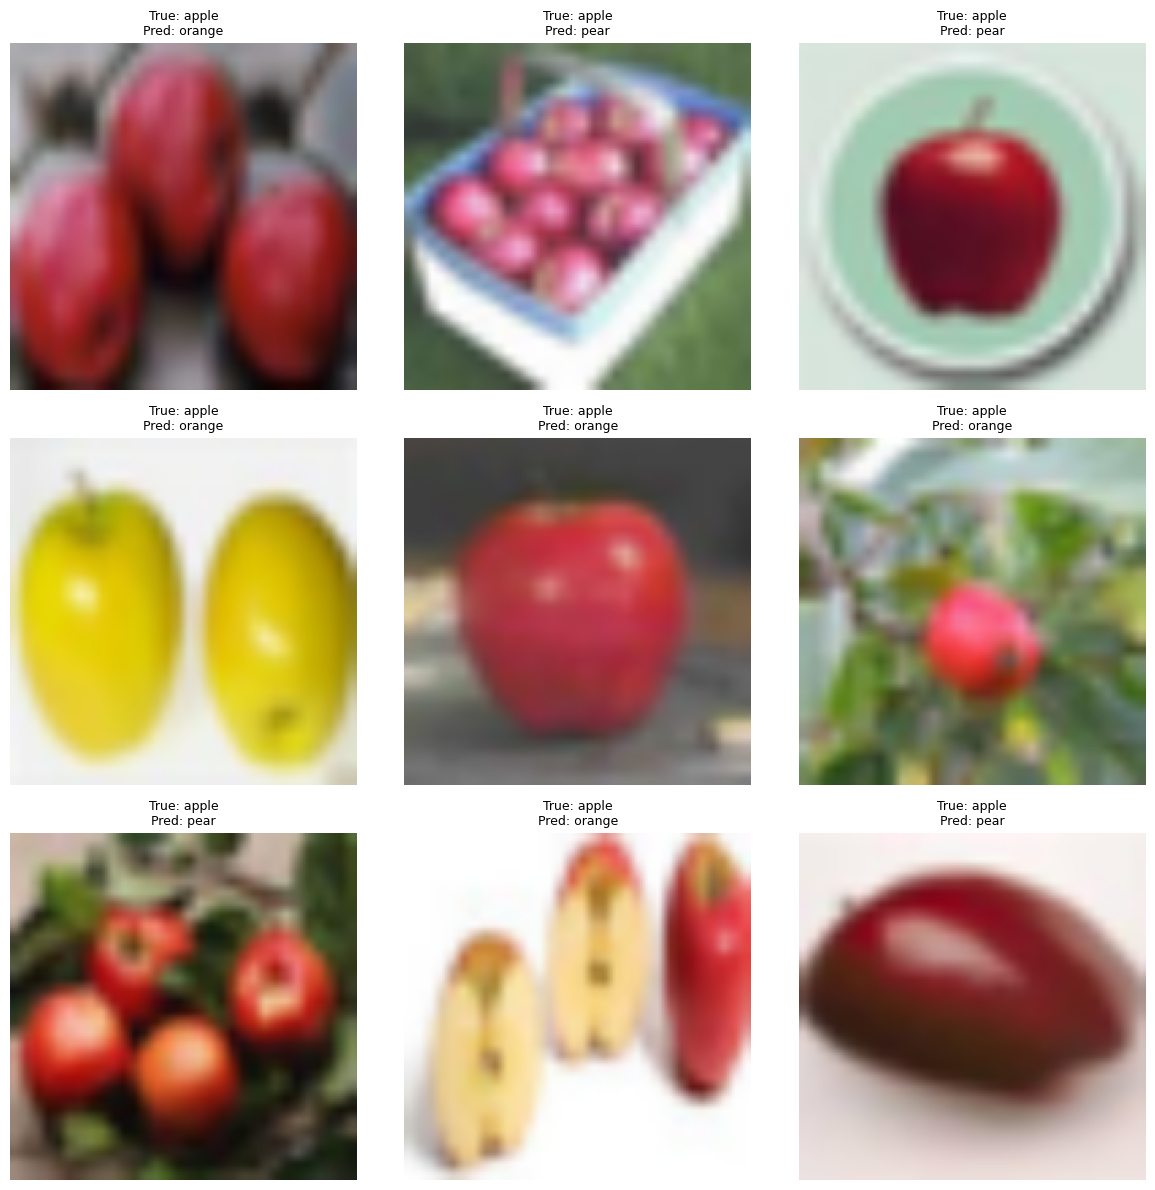

In [34]:
show_misclassified_examples_standalone(model_resnet, test_ds, cifar100_fine_labels)

In [35]:
results = {
    'ResNet50V2': {
        'training_time': train_time_resnet,
        'val_accuracy': history_resnet.history['val_accuracy'][-1],
        'history': history_resnet
    }
}

### **Model B: MobileNetV2 with Frozen Backbone**

In [36]:
base_model_mobilenet = tf.keras.applications.MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [38]:
base_model_mobilenet.trainable = False

model_mobilenet = build_model(base_model_mobilenet,NUM_CLASSES)

model_mobilenet.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │       128,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,386,084 (9.10 MB)

 Trainable params: 128,100 (500.39 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [39]:
history_mobilenet, train_time_mobilenet = train_model(model_mobilenet, "MobileNetV2", train_ds, test_ds, BATCH_SIZE)

Epoch 1/5


2026-09-03 11:16:15.710119: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-03 11:16:15.847008: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1559/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4160 - loss: 2.4132

2026-09-03 11:16:44.539898: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-03 11:16:44.677705: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-03 11:16:44.814629: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4163 - loss: 2.4117

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 57s 26ms/step - accuracy: 0.5173 - loss: 1.8457 - val_accuracy: 0.6139 - val_loss: 1.3796 - learning_rate: 9.5000e-04
Epoch 2/5
1560/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6338 - loss: 1.2966

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.6351 - loss: 1.2937 - val_accuracy: 0.6241 - val_loss: 1.3439 - learning_rate: 9.0250e-04
Epoch 3/5
1559/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6730 - loss: 1.1410

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.6721 - loss: 1.1468 - val_accuracy: 0.6367 - val_loss: 1.3270 - learning_rate: 8.5737e-04
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.6922 - loss: 1.0591 - val_accuracy: 0.6360 - val_loss: 1.3360 - learning_rate: 8.1451e-04
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.7083 - loss: 0.9945 - val_accuracy: 0.6363 - val_loss: 1.3475 - learning_rate: 7.7378e-04
MobileNetV2 Training Time: 142.04 seconds
MobileNetV2 Best Val Accuracy: 0.6367


#### **Results of MobileNetV2**

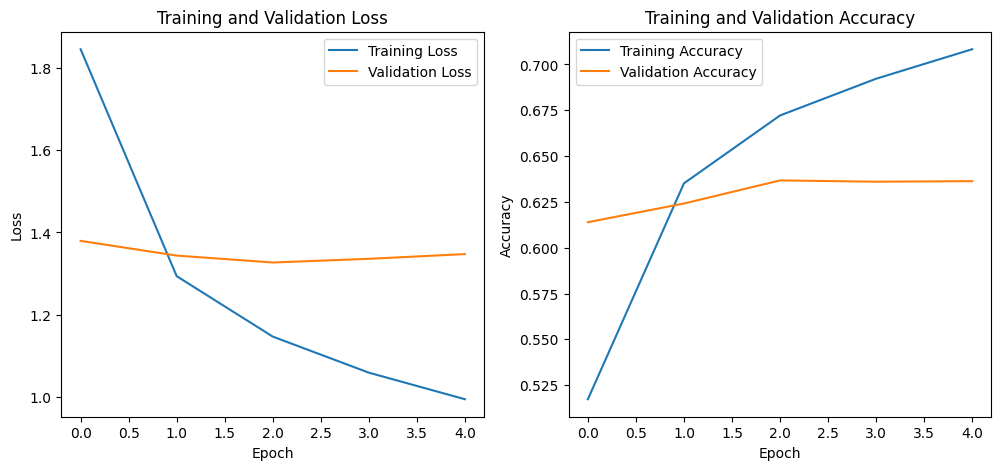

In [40]:
plot_loss_accuracy_comparison(history_mobilenet)


Confusion Matrix & Classification Report
----------------------------------------
               precision    recall  f1-score   support

        apple       0.86      0.87      0.87       100
aquarium_fish       0.84      0.74      0.79       100
         baby       0.40      0.59      0.48       100
         bear       0.41      0.58      0.48       100
       beaver       0.40      0.38      0.39       100
          bed       0.56      0.76      0.64       100
          bee       0.79      0.59      0.67       100
       beetle       0.69      0.69      0.69       100
      bicycle       0.78      0.76      0.77       100
       bottle       0.89      0.84      0.87       100
         bowl       0.61      0.47      0.53       100
          boy       0.52      0.27      0.36       100
       bridge       0.64      0.77      0.70       100
          bus       0.73      0.47      0.57       100
    butterfly       0.74      0.61      0.67       100
        camel       0.73      0.52  

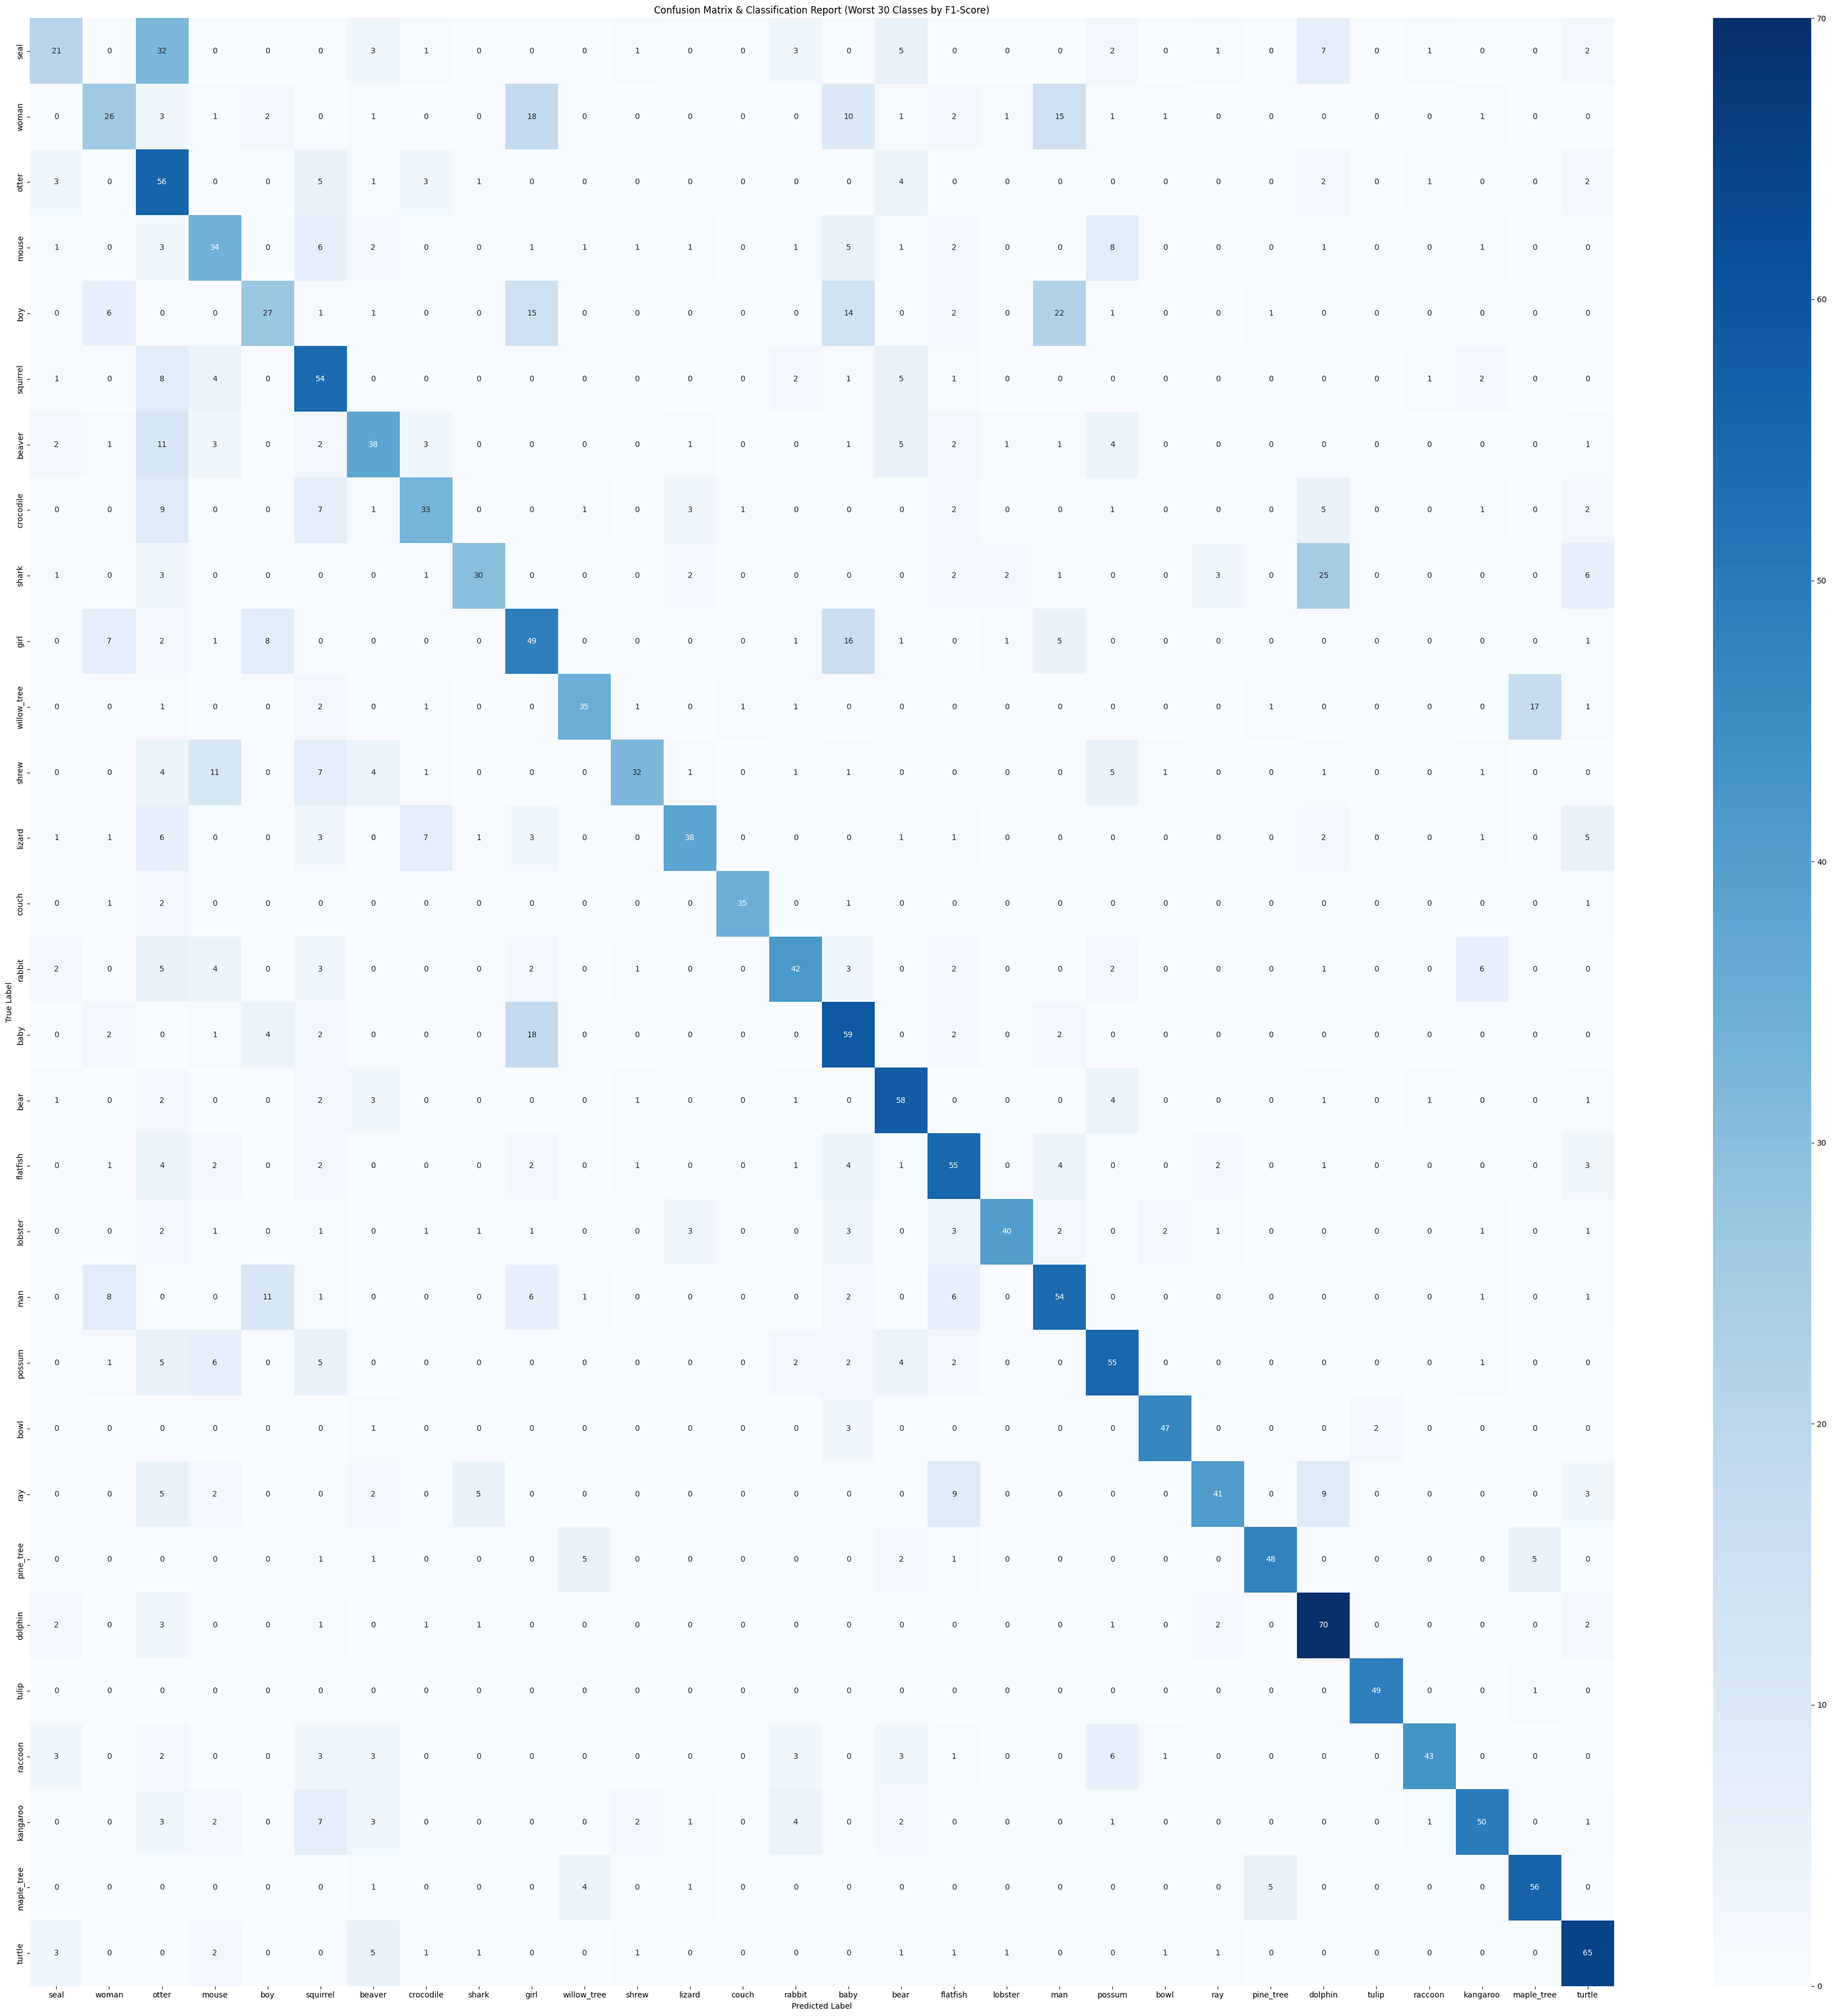

In [41]:
confusion_matrix_and_classification_report(model_mobilenet, test_ds,
                                           class_names=cifar100_fine_labels, display_confusion_for_worst_n_classes=30)

Found 3633 misclassified examples out of 10000 total


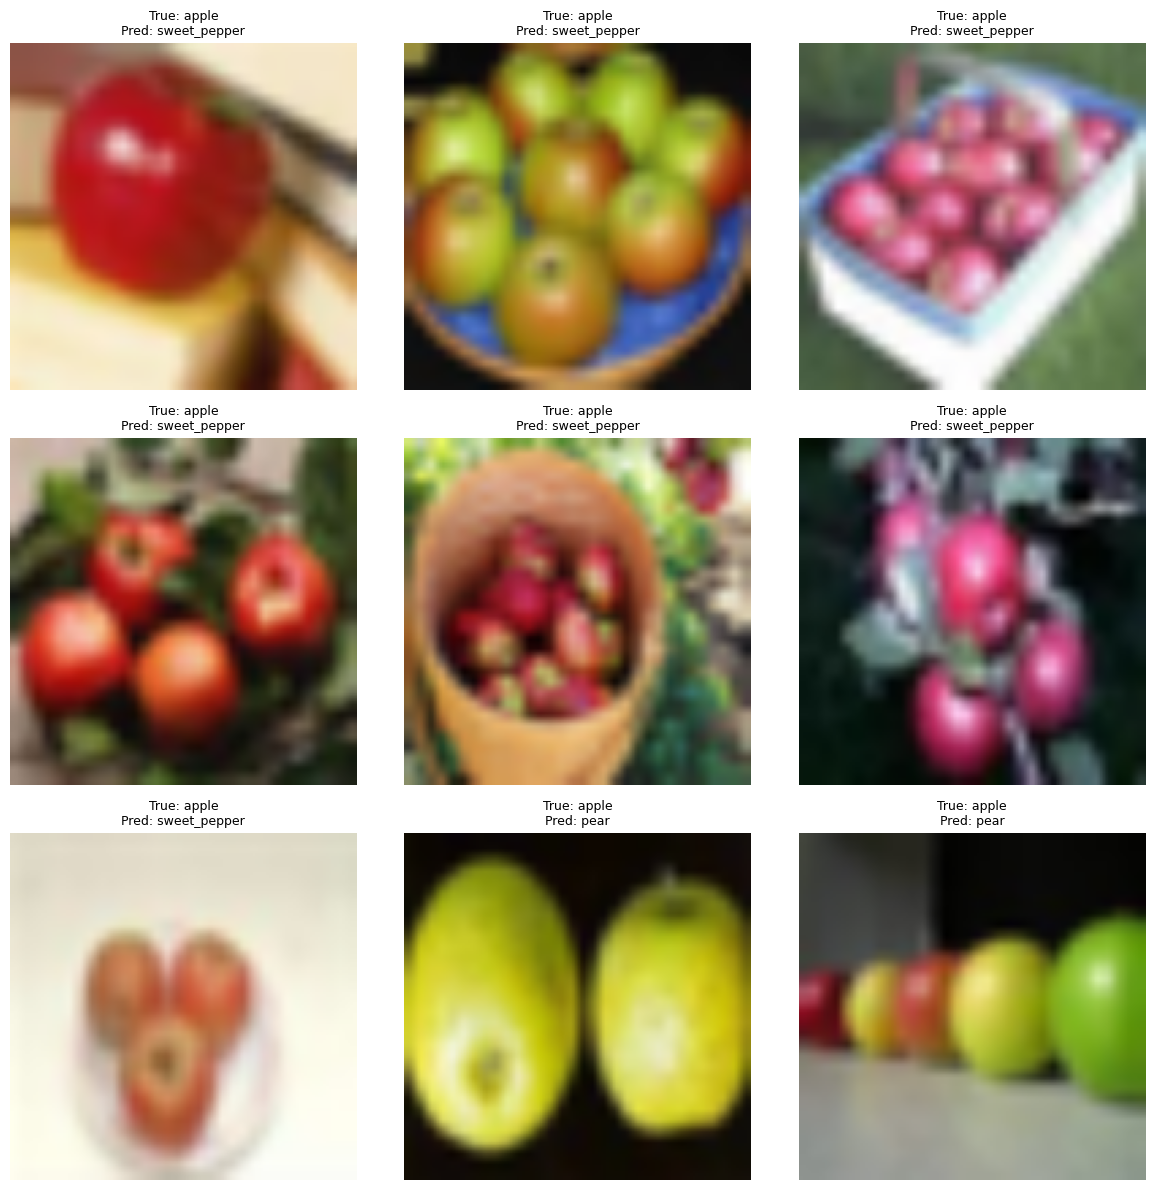

In [42]:
show_misclassified_examples_standalone(model_mobilenet, test_ds, cifar100_fine_labels)

In [43]:
results['MobileNetV2'] = {
    'training_time': train_time_mobilenet,
    'val_accuracy': history_mobilenet.history['val_accuracy'][-1],
    'history': history_mobilenet
}

### **Comparison of Models (ResNet50V2 vs. MobileNetV2)**

In [44]:
for model_name, data in results.items():
    print(f"Model: {model_name}")
    print(f"  Training Time: {data['training_time']:.2f} seconds")
    print(f"  Validation Accuracy: {data['val_accuracy']:.4f}")
    print(f"  Effiency -> Accuracy / Seconds : {results[model_name]['val_accuracy'] / results[model_name]['training_time']}")

best_accuracy = max(results, key=lambda k: results[k]['val_accuracy'])

best_time = min(results, key=lambda k: results[k]['training_time'])

best_efficiency = max(results, key=lambda k: results[k]['val_accuracy'] / results[k]['training_time'])

print(f"\nBest by Accuracy: {best_accuracy} ({results[best_accuracy]['val_accuracy']:.4f})")
print(f"Best by Time: {best_time} ({results[best_time]['training_time']:.4f})")
print(f"Efficient (accuracy/sec): {best_efficiency} ({results[best_efficiency]['val_accuracy']/results[best_efficiency]['training_time']:.6f})")

Model: ResNet50V2
  Training Time: 221.81 seconds
  Validation Accuracy: 0.6054
  Effiency -> Accuracy / Seconds : 0.0027293734328354222
Model: MobileNetV2
  Training Time: 142.04 seconds
  Validation Accuracy: 0.6363
  Effiency -> Accuracy / Seconds : 0.00447970480792431

Best by Accuracy: MobileNetV2 (0.6363)
Best by Time: MobileNetV2 (142.0406)
Efficient (accuracy/sec): MobileNetV2 (0.004480)


Best Model by Accuracy & Time: MobileNetV2 

Most Efficient Model (accuracy/sec): MobileNetV2

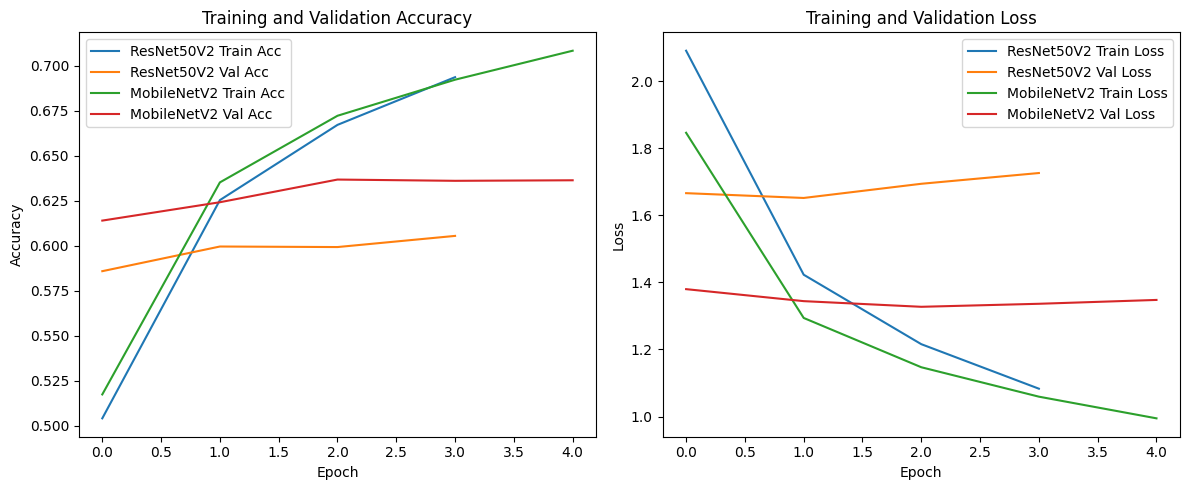

In [45]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(results['ResNet50V2']['history'].history['accuracy'], label='ResNet50V2 Train Acc')
plt.plot(results['ResNet50V2']['history'].history['val_accuracy'], label='ResNet50V2 Val Acc')
plt.plot(results['MobileNetV2']['history'].history['accuracy'], label='MobileNetV2 Train Acc')
plt.plot(results['MobileNetV2']['history'].history['val_accuracy'], label='MobileNetV2 Val Acc')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(results['ResNet50V2']['history'].history['loss'], label='ResNet50V2 Train Loss')
plt.plot(results['ResNet50V2']['history'].history['val_loss'], label='ResNet50V2 Val Loss')
plt.plot(results['MobileNetV2']['history'].history['loss'], label='MobileNetV2 Train Loss')
plt.plot(results['MobileNetV2']['history'].history['val_loss'], label='MobileNetV2 Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


## **Phase 2: Percentage-Based Unfreezing**

### **Strategy A: Top 10% Unfreezing for MobileNetV2**

In [46]:
base_model_mobilenet_unfreeze_10 = keras.applications.MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

In [47]:
model_mobilenet_10 = build_model(base_model_mobilenet_unfreeze_10, NUM_CLASSES)

base_model_mobilenet_unfreeze_10.trainable = True

total_layers_mobile_net = len(base_model_mobilenet_unfreeze_10.layers)
unfreeze_percentage_10 = 0.10
freeze_until_10 = int(total_layers_mobile_net * (1.0 - unfreeze_percentage_10))

for layer in base_model_mobilenet_unfreeze_10.layers[:freeze_until_10]:
    layer.trainable = False

In [48]:
model_mobilenet_10.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │       128,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,386,084 (9.10 MB)

 Trainable params: 1,170,020 (4.46 MB)

 Non-trainable params: 1,216,064 (4.64 MB)

In [49]:
history_mobilenet_10, train_time_mobilenet_10 = train_model(
    model_mobilenet_10, 
    'anything',
    train_ds, 
    test_ds, 
    BATCH_SIZE
)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4724 - loss: 2.0589

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 51s 24ms/step - accuracy: 0.5457 - loss: 1.6673 - val_accuracy: 0.3113 - val_loss: 4.1827 - learning_rate: 9.5000e-04
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.6679 - loss: 1.1381 - val_accuracy: 0.3328 - val_loss: 4.3237 - learning_rate: 9.0250e-04
Epoch 3/5
1561/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7177 - loss: 0.9435

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.7291 - loss: 0.9102 - val_accuracy: 0.4484 - val_loss: 2.8886 - learning_rate: 8.5737e-04
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.7730 - loss: 0.7293 - val_accuracy: 0.4941 - val_loss: 2.9392 - learning_rate: 8.1451e-04
Epoch 5/5
1560/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8116 - loss: 0.5950

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.8198 - loss: 0.5658 - val_accuracy: 0.5269 - val_loss: 2.8494 - learning_rate: 7.7378e-04
anything Training Time: 145.74 seconds
anything Best Val Accuracy: 0.5269


#### **Results**

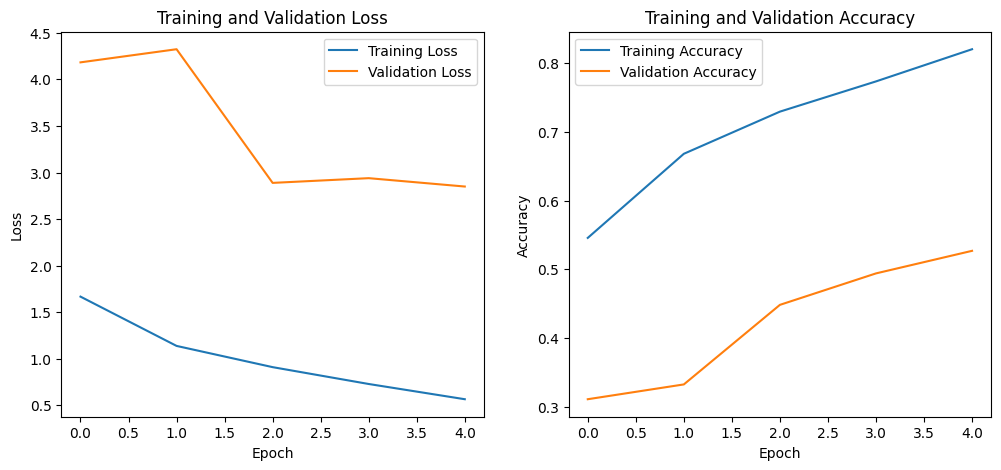

In [50]:
plot_loss_accuracy_comparison(history_mobilenet_10)


Confusion Matrix & Classification Report
----------------------------------------
               precision    recall  f1-score   support

        apple       0.74      0.86      0.79       100
aquarium_fish       0.97      0.36      0.53       100
         baby       0.41      0.64      0.50       100
         bear       0.89      0.16      0.27       100
       beaver       0.74      0.20      0.31       100
          bed       0.71      0.65      0.68       100
          bee       0.82      0.37      0.51       100
       beetle       0.83      0.55      0.66       100
      bicycle       0.30      0.88      0.45       100
       bottle       0.76      0.79      0.77       100
         bowl       0.46      0.38      0.42       100
          boy       0.49      0.20      0.28       100
       bridge       0.78      0.63      0.70       100
          bus       0.56      0.67      0.61       100
    butterfly       0.81      0.57      0.67       100
        camel       0.56      0.62  

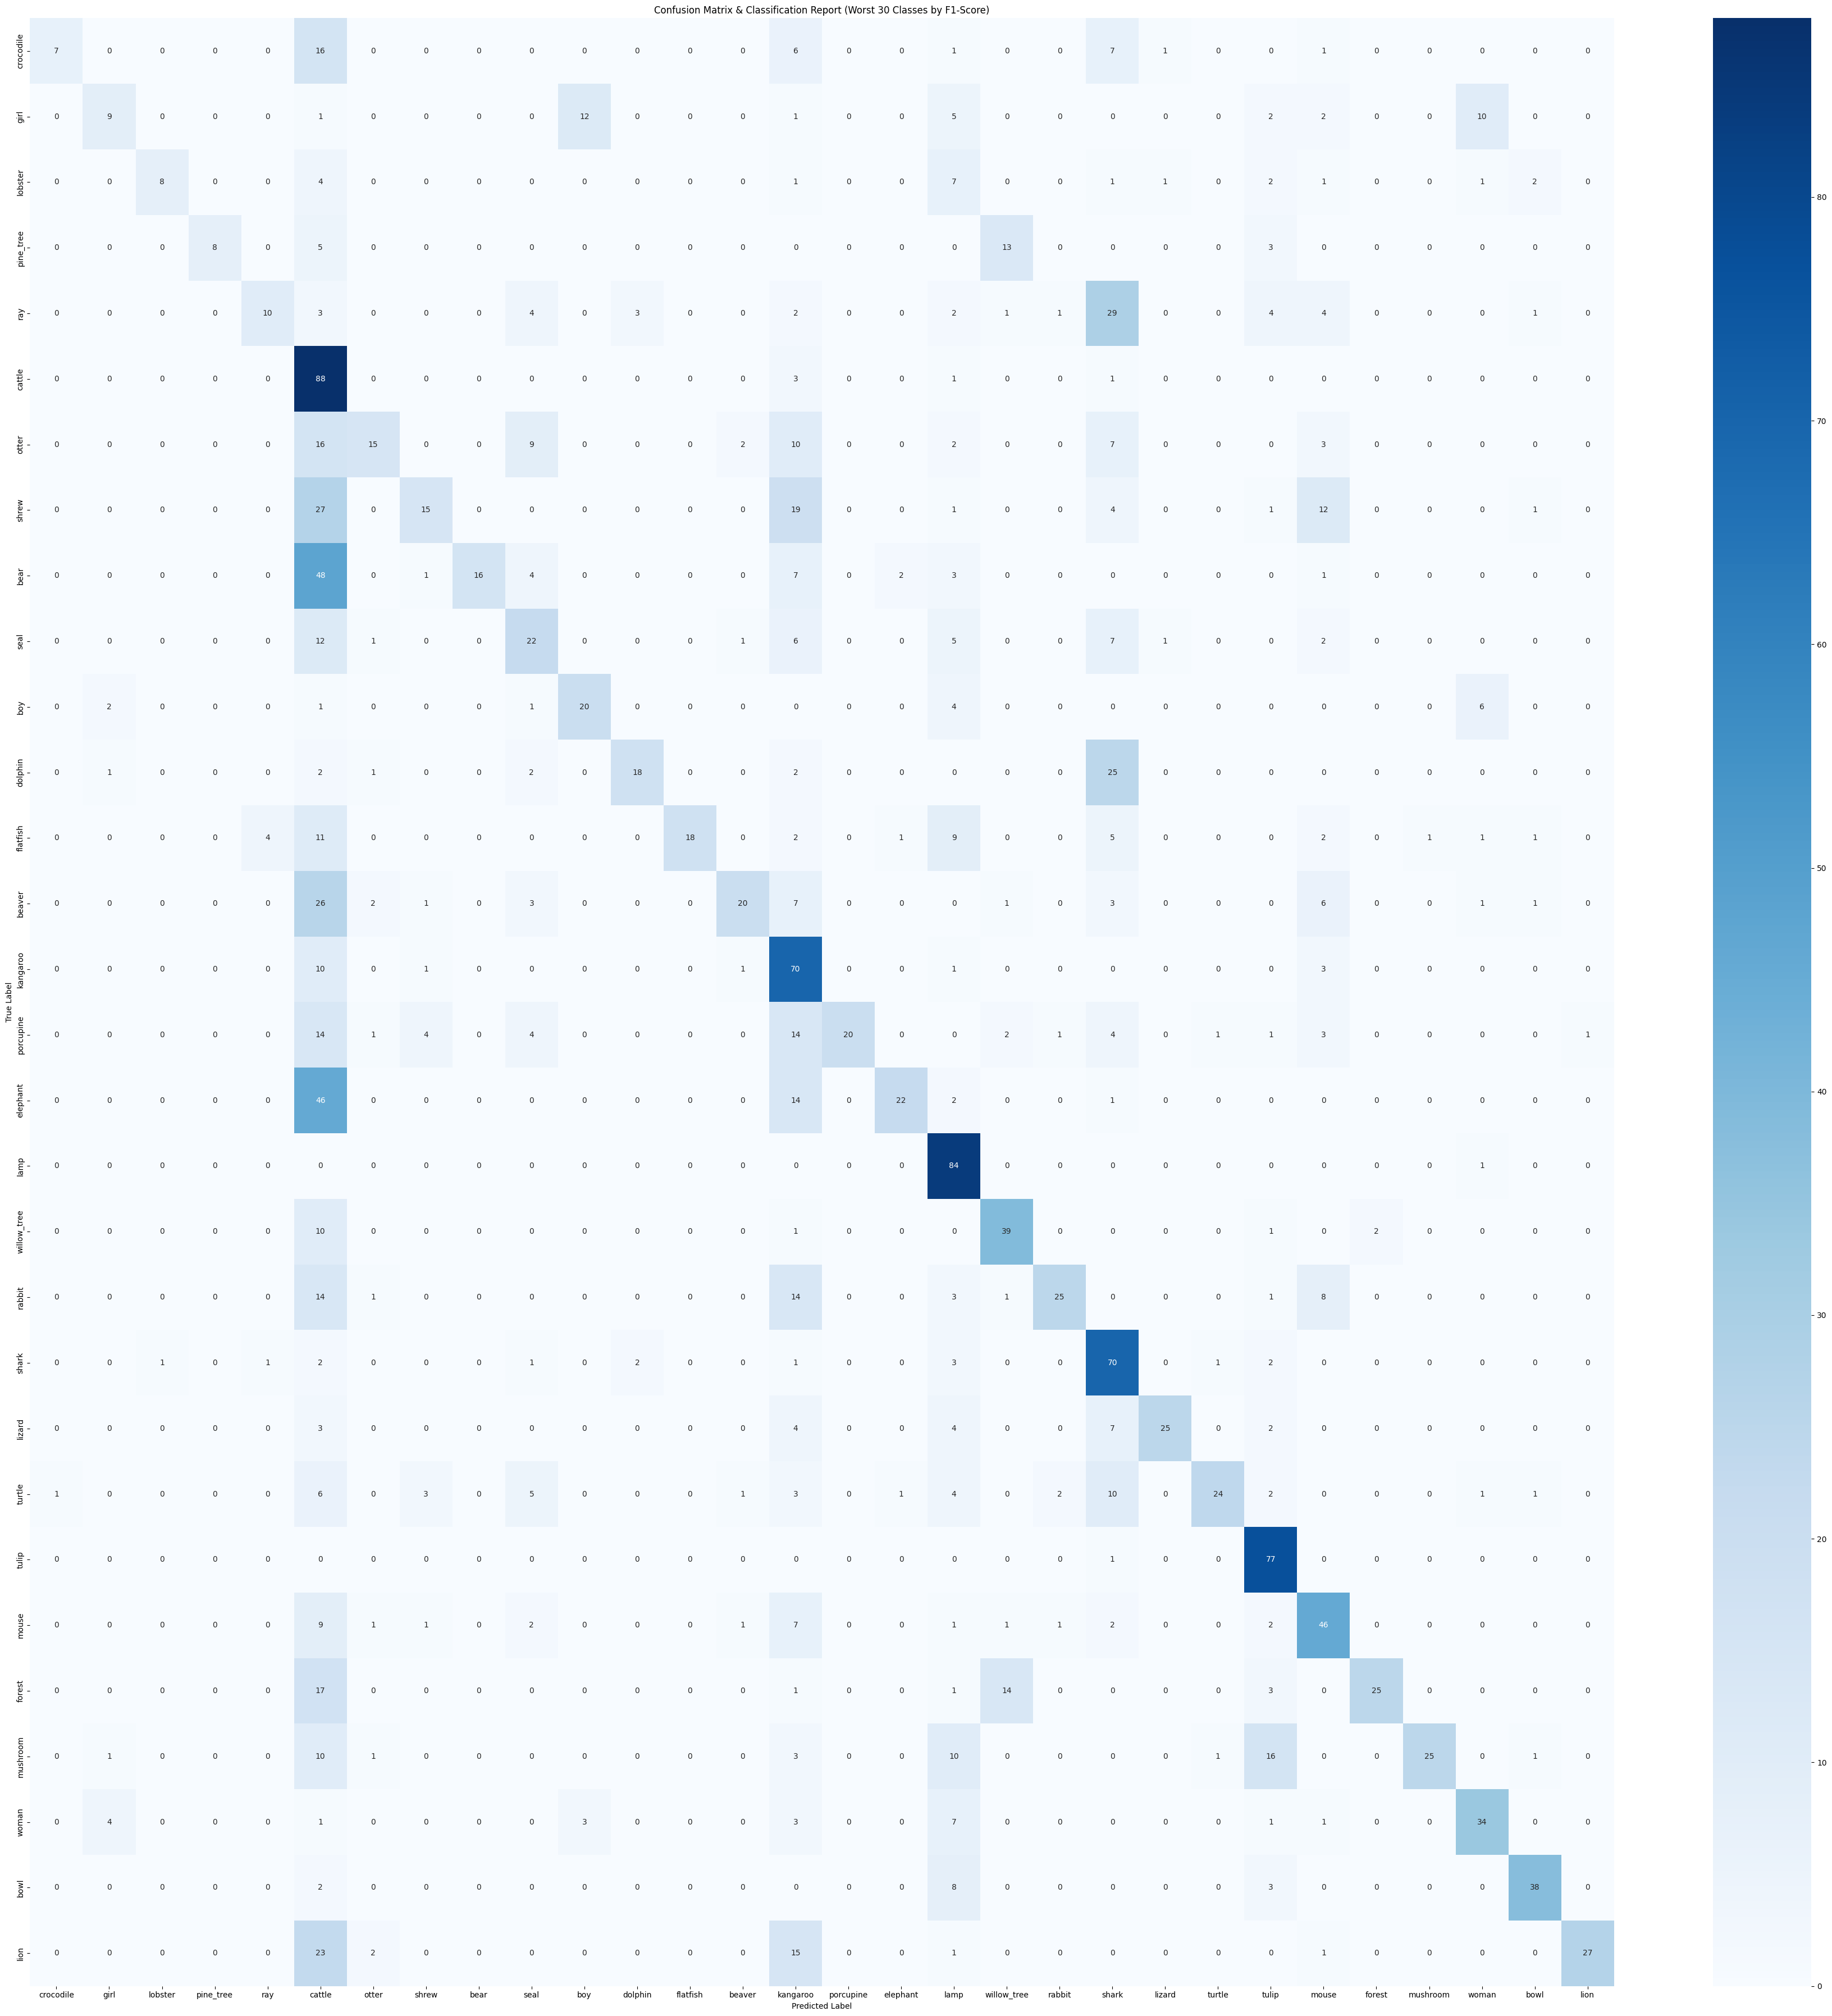

In [51]:
confusion_matrix_and_classification_report(model_mobilenet_10, test_ds,
                                           class_names=cifar100_fine_labels, display_confusion_for_worst_n_classes=30)

Found 4731 misclassified examples out of 10000 total


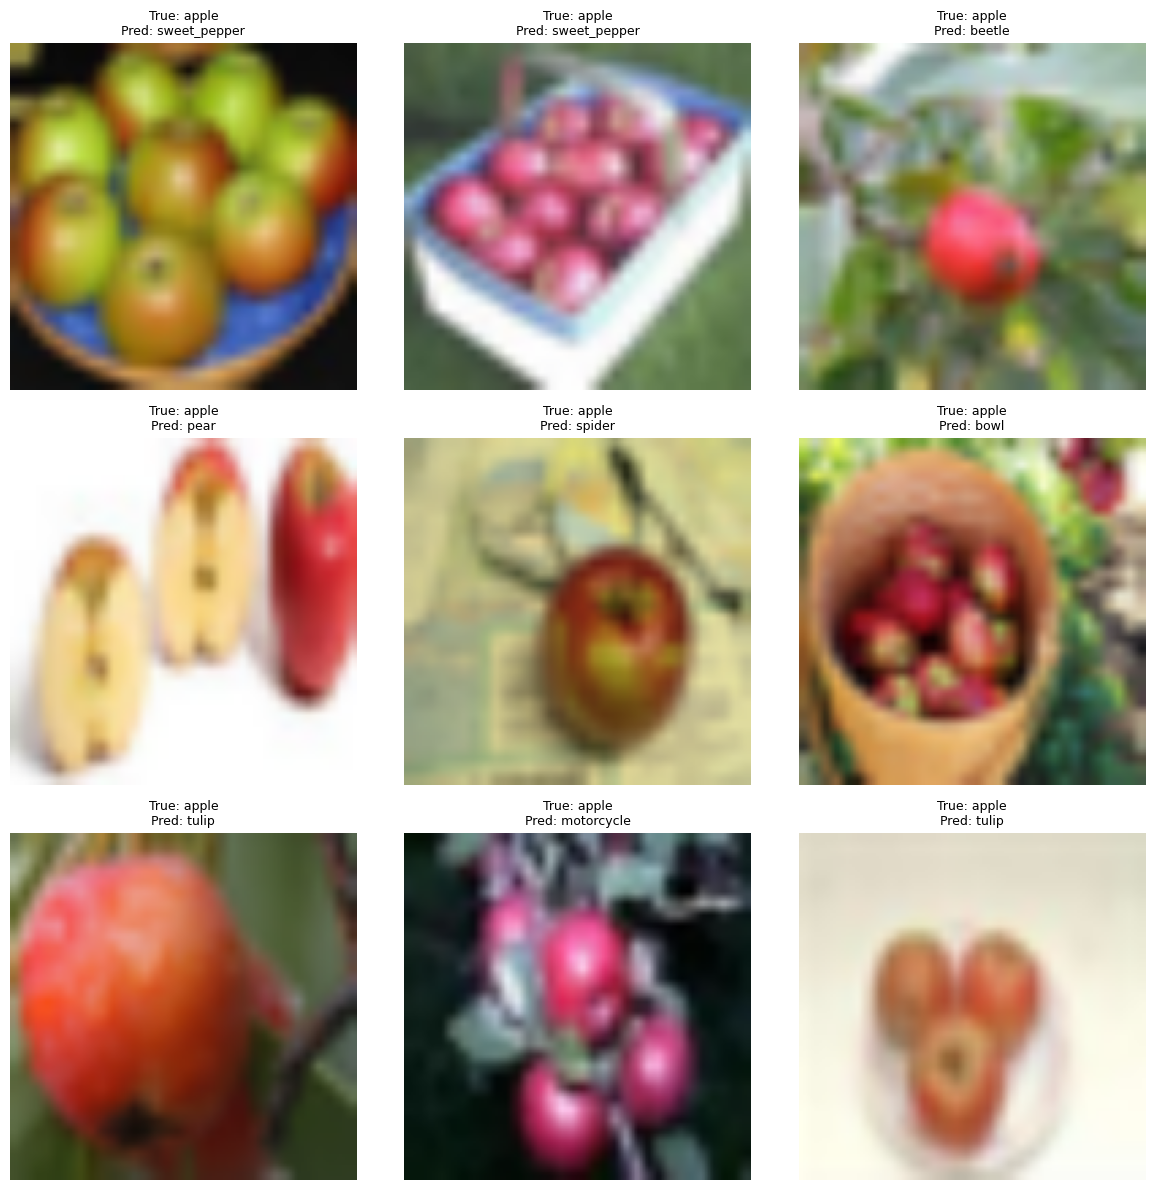

In [52]:
show_misclassified_examples_standalone(model_mobilenet_10, test_ds, cifar100_fine_labels)

In [53]:
results['MobileNetV2_Unfreeze_10%'] = {
    'training_time': train_time_mobilenet_10,
    'val_accuracy': history_mobilenet_10.history['val_accuracy'][-1],
    'history': history_mobilenet_10
}

### **Strategy B: Deep 35% Unfreezing for MobileNetV2**

In [54]:
base_model_mobilenet_unfreeze_35 = keras.applications.MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

In [56]:
model_mobilenet_35 = build_model(base_model_mobilenet_unfreeze_35, NUM_CLASSES)

base_model_mobilenet_unfreeze_35.trainable = True

total_layers_mobile_net = len(base_model_mobilenet_unfreeze_35.layers)
unfreeze_percentage_35 = 0.35
freeze_until_35 = int(total_layers_mobile_net * (1.0 - unfreeze_percentage_35))

for layer in base_model_mobilenet_unfreeze_35.layers[:freeze_until_35]:
    layer.trainable = False

In [57]:
model_mobilenet_35.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │       128,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,386,084 (9.10 MB)

 Trainable params: 1,989,540 (7.59 MB)

 Non-trainable params: 396,544 (1.51 MB)

In [58]:
history_mobilenet_35, train_time_mobilenet_35 = train_model(
    model_mobilenet_35, 
    'anything',
    train_ds, 
    test_ds, 
    BATCH_SIZE
)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4260 - loss: 2.2437

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 32ms/step - accuracy: 0.5114 - loss: 1.8004 - val_accuracy: 0.3465 - val_loss: 4.0365 - learning_rate: 9.5000e-04
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.6483 - loss: 1.2080 - val_accuracy: 0.3526 - val_loss: 4.0929 - learning_rate: 9.0250e-04
Epoch 3/5
1560/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6993 - loss: 1.0117

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.7112 - loss: 0.9649 - val_accuracy: 0.5130 - val_loss: 2.4347 - learning_rate: 8.5737e-04
Epoch 4/5
1561/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7493 - loss: 0.8158

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.7619 - loss: 0.7746 - val_accuracy: 0.5795 - val_loss: 2.0151 - learning_rate: 8.1451e-04
Epoch 5/5
1562/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7950 - loss: 0.6498

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.8040 - loss: 0.6168 - val_accuracy: 0.5895 - val_loss: 1.9249 - learning_rate: 7.7378e-04
anything Training Time: 196.04 seconds
anything Best Val Accuracy: 0.5895


#### **Results**

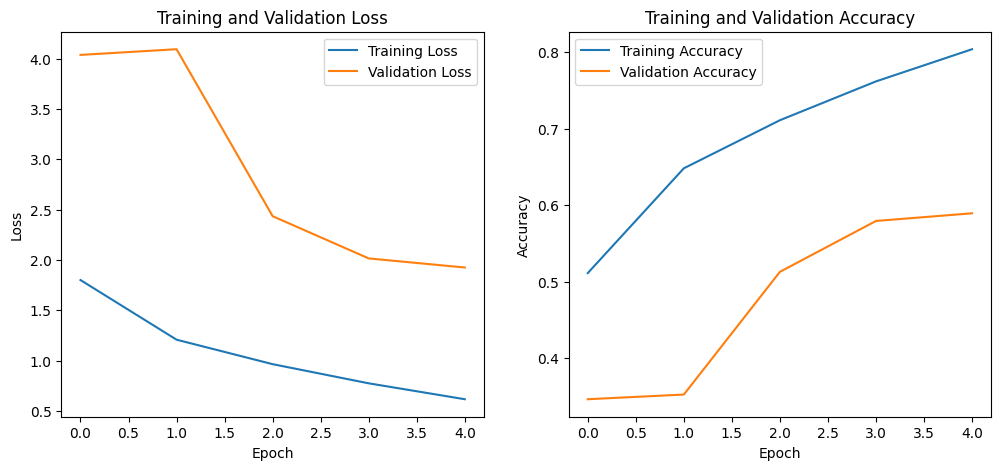

In [62]:
plot_loss_accuracy_comparison(history_mobilenet_35)


Confusion Matrix & Classification Report
----------------------------------------
               precision    recall  f1-score   support

        apple       0.79      0.83      0.81       100
aquarium_fish       0.94      0.62      0.75       100
         baby       0.84      0.27      0.41       100
         bear       0.63      0.36      0.46       100
       beaver       0.60      0.29      0.39       100
          bed       0.87      0.45      0.59       100
          bee       0.94      0.46      0.62       100
       beetle       0.59      0.71      0.65       100
      bicycle       0.56      0.97      0.71       100
       bottle       0.87      0.80      0.83       100
         bowl       0.69      0.29      0.41       100
          boy       0.47      0.34      0.39       100
       bridge       0.36      0.82      0.50       100
          bus       0.53      0.62      0.57       100
    butterfly       0.85      0.60      0.70       100
        camel       0.68      0.66  

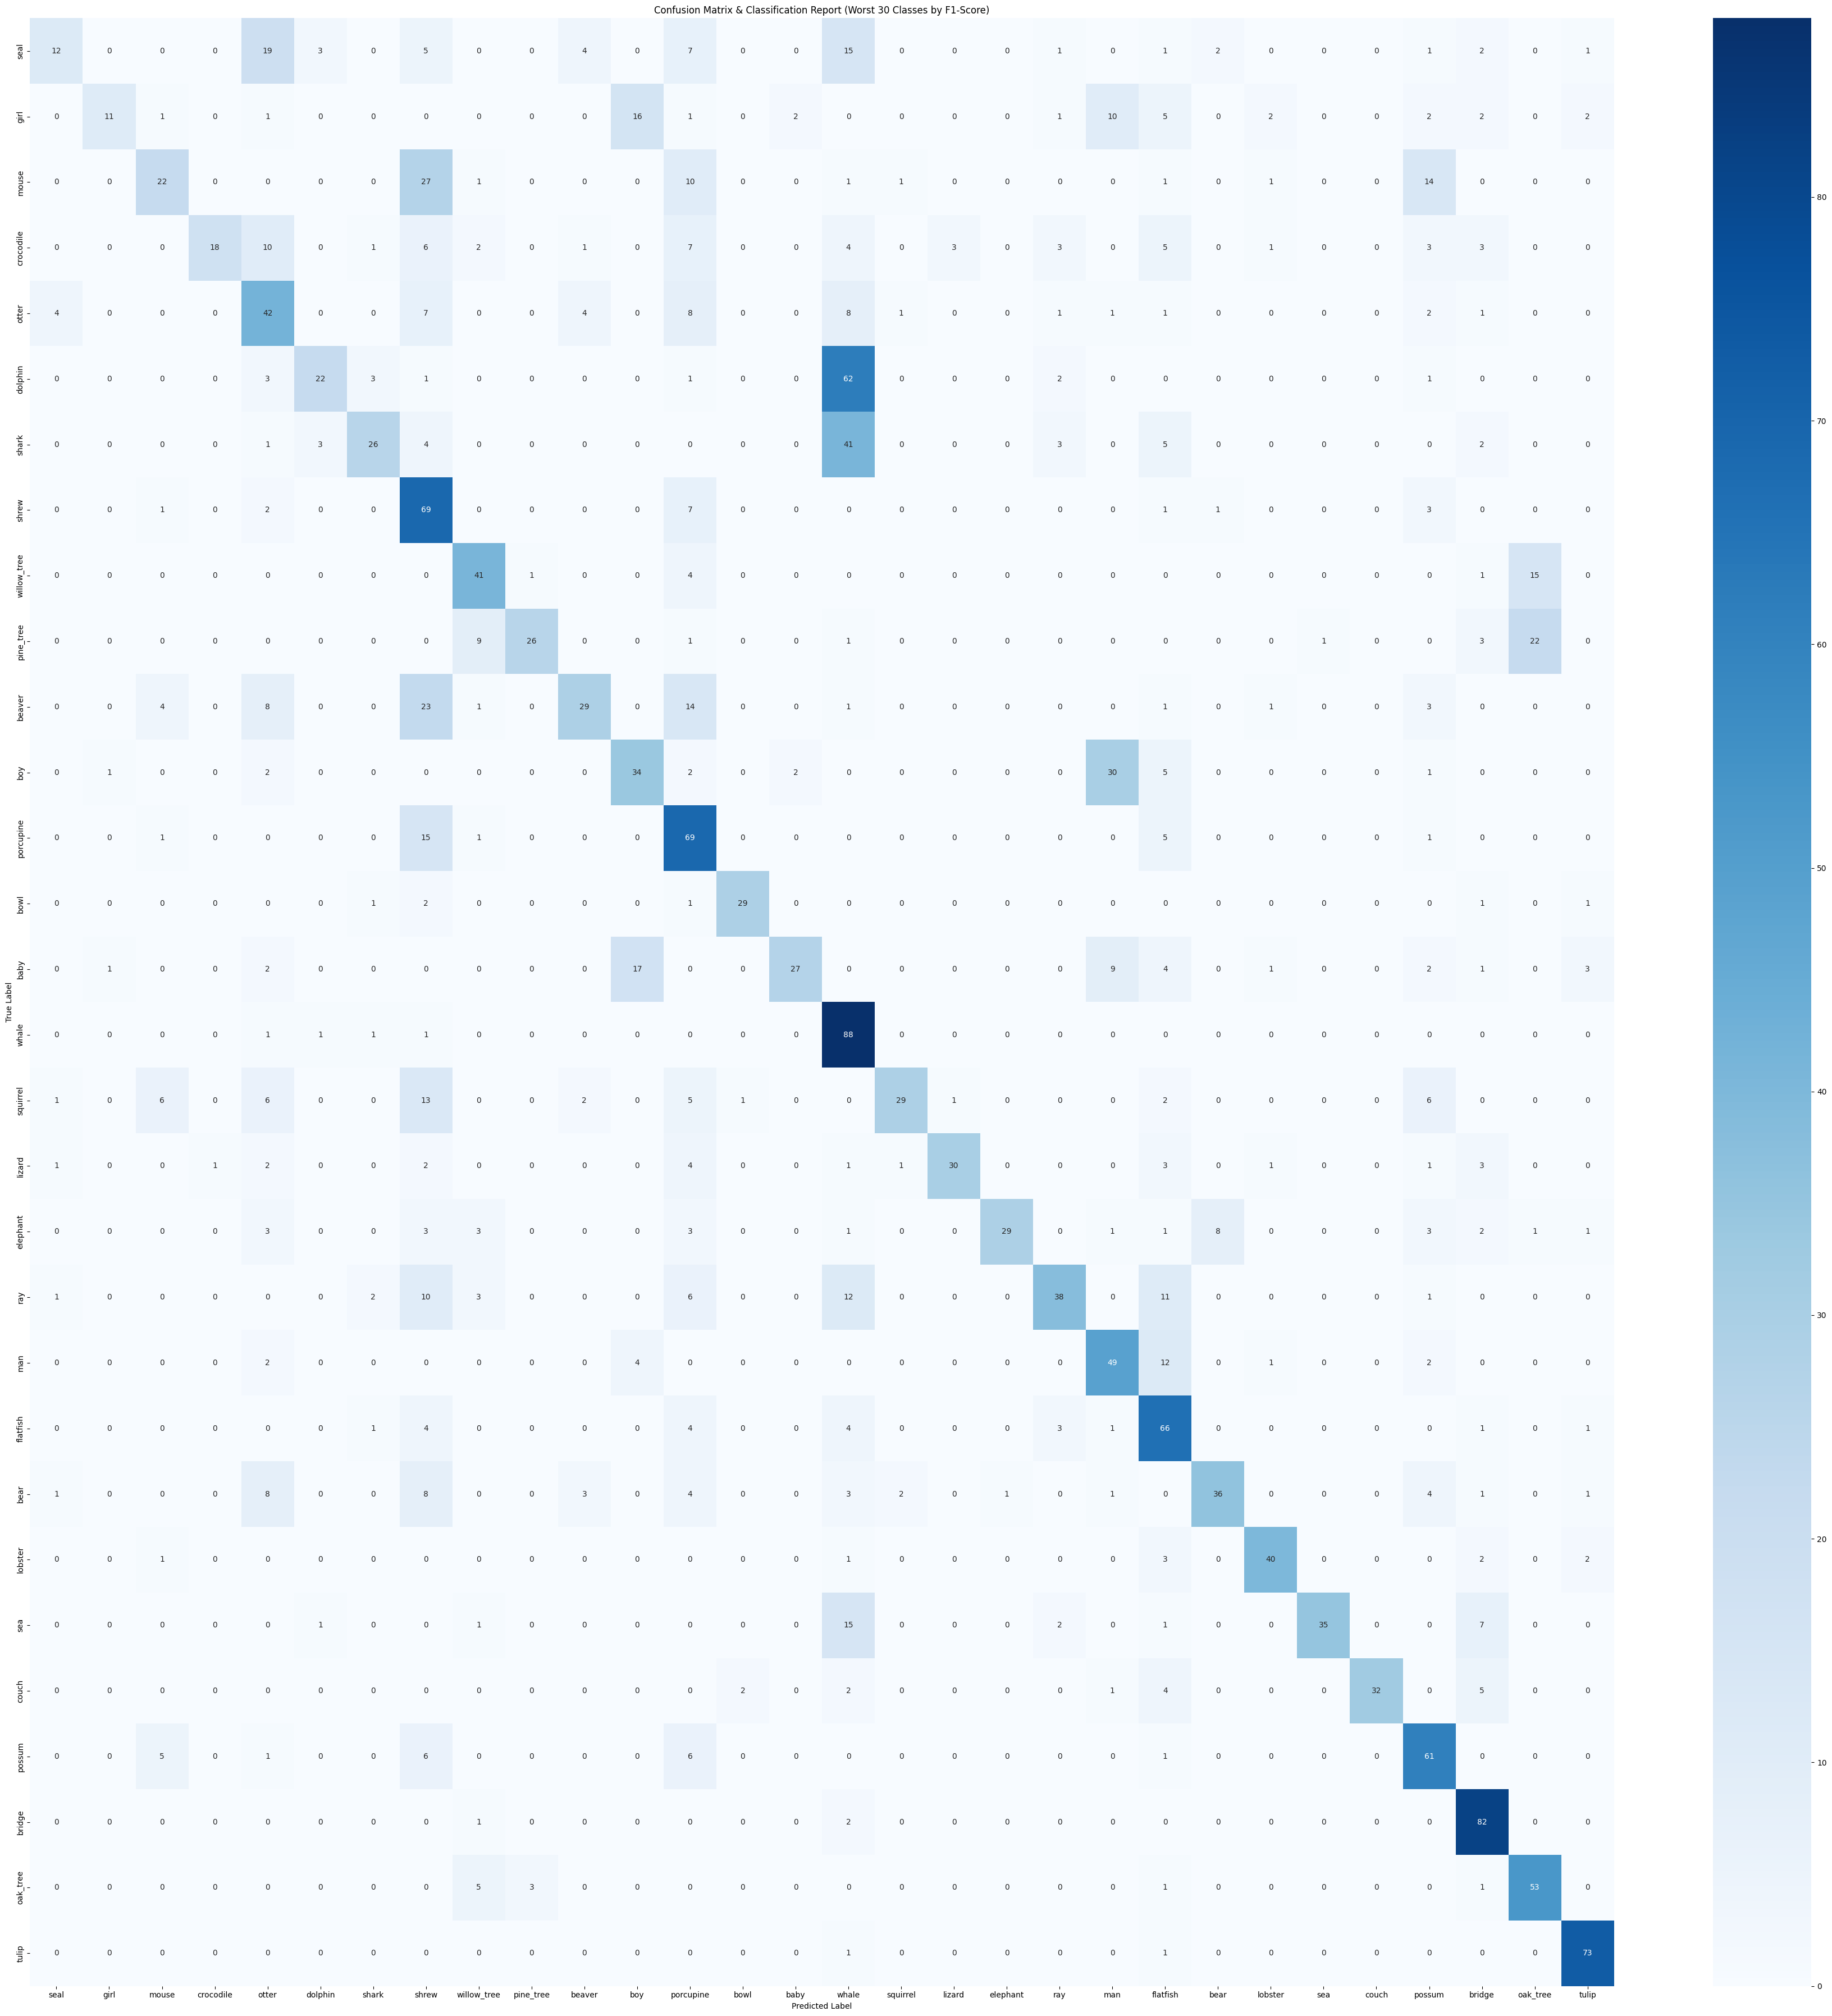

In [66]:
confusion_matrix_and_classification_report(model_mobilenet_35, test_ds,
                                           class_names=cifar100_fine_labels, display_confusion_for_worst_n_classes=30)

Found 4105 misclassified examples out of 10000 total


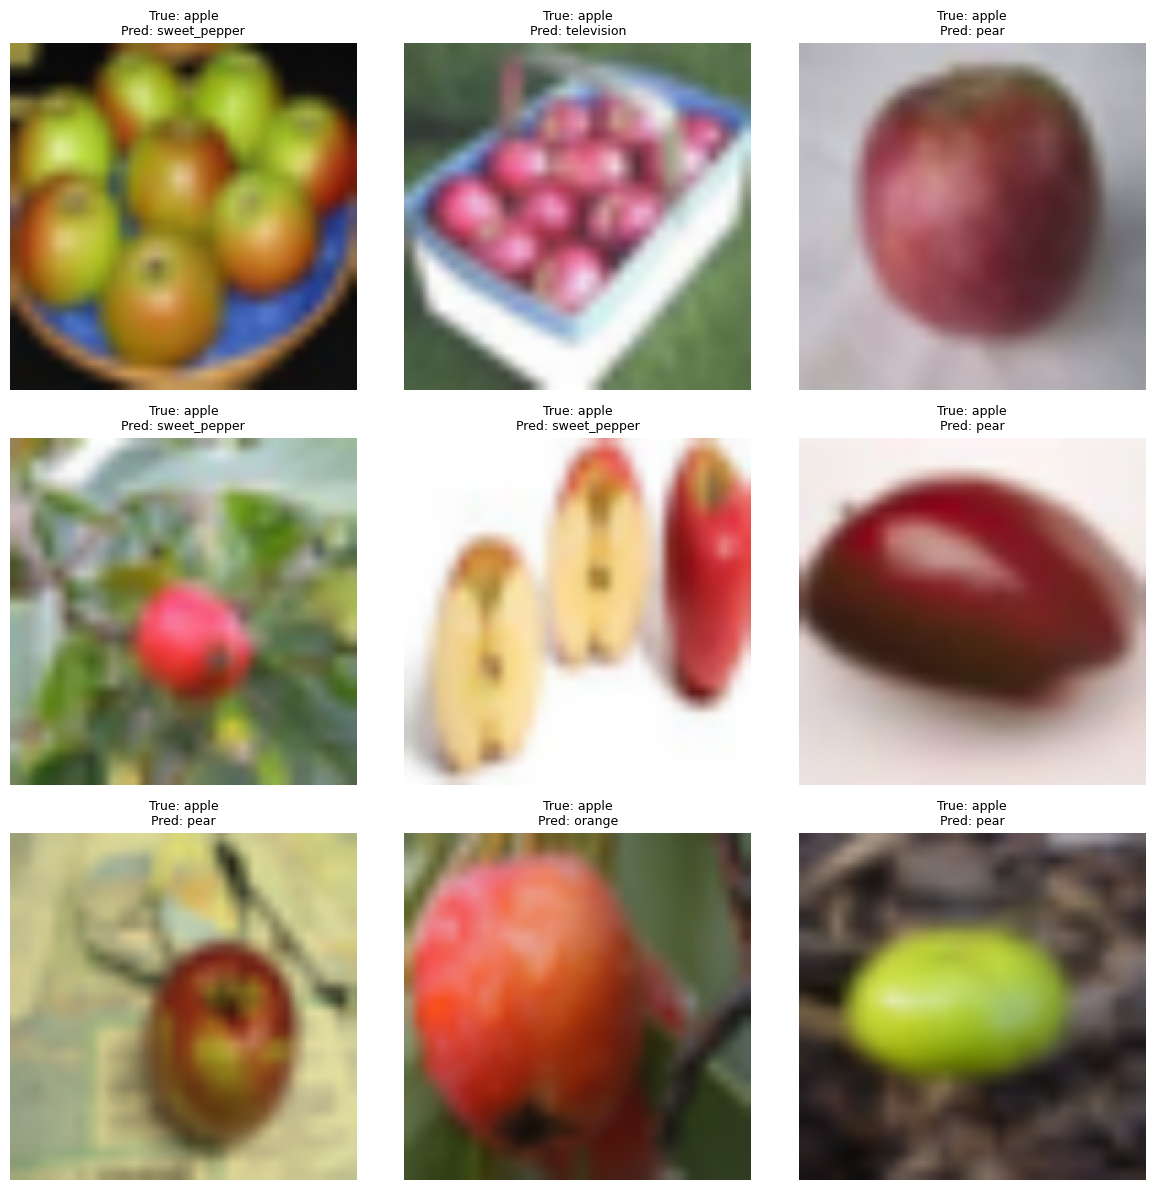

In [84]:
show_misclassified_examples_standalone(model_mobilenet_35, test_ds, cifar100_fine_labels)

In [68]:
results['MobileNetV2_Unfreeze_35%'] = {
    'training_time': train_time_mobilenet_35,
    'val_accuracy': history_mobilenet_35.history['val_accuracy'][-1],
    'history': history_mobilenet_35
}

### **Comparison of Fine-Tuning Strategies**

In [69]:
for model_name, data in results.items():
    print(f"Model: {model_name}")
    print(f"  Training Time: {data['training_time']:.2f} seconds")
    print(f"  Validation Accuracy: {data['val_accuracy']:.4f}")
    print(f"  Effiency -> Accuracy / Seconds : {results[model_name]['val_accuracy'] / results[model_name]['training_time']}")

best_accuracy = max(results, key=lambda k: results[k]['val_accuracy'])

best_time = min(results, key=lambda k: results[k]['training_time'])

best_efficiency = max(results, key=lambda k: results[k]['val_accuracy'] / results[k]['training_time'])

print(f"\nBest by Accuracy: {best_accuracy} ({results[best_accuracy]['val_accuracy']:.4f})")
print(f"Best by Time: {best_time} ({results[best_time]['training_time']:.4f})")
print(f"Efficient (accuracy/sec): {best_efficiency} ({results[best_efficiency]['val_accuracy']/results[best_efficiency]['training_time']:.6f})")

Model: ResNet50V2
  Training Time: 221.81 seconds
  Validation Accuracy: 0.6054
  Effiency -> Accuracy / Seconds : 0.0027293734328354222
Model: MobileNetV2
  Training Time: 142.04 seconds
  Validation Accuracy: 0.6363
  Effiency -> Accuracy / Seconds : 0.00447970480792431
Model: MobileNetV2_Unfreeze_10%
  Training Time: 145.74 seconds
  Validation Accuracy: 0.5269
  Effiency -> Accuracy / Seconds : 0.00361545383506532
Model: MobileNetV2_Unfreeze_35%
  Training Time: 196.04 seconds
  Validation Accuracy: 0.5895
  Effiency -> Accuracy / Seconds : 0.003006964364364627

Best by Accuracy: MobileNetV2 (0.6363)
Best by Time: MobileNetV2 (142.0406)
Efficient (accuracy/sec): MobileNetV2 (0.004480)


best is freezed mobilenet  
and second option is mobilenet with 10% unfreeze layers

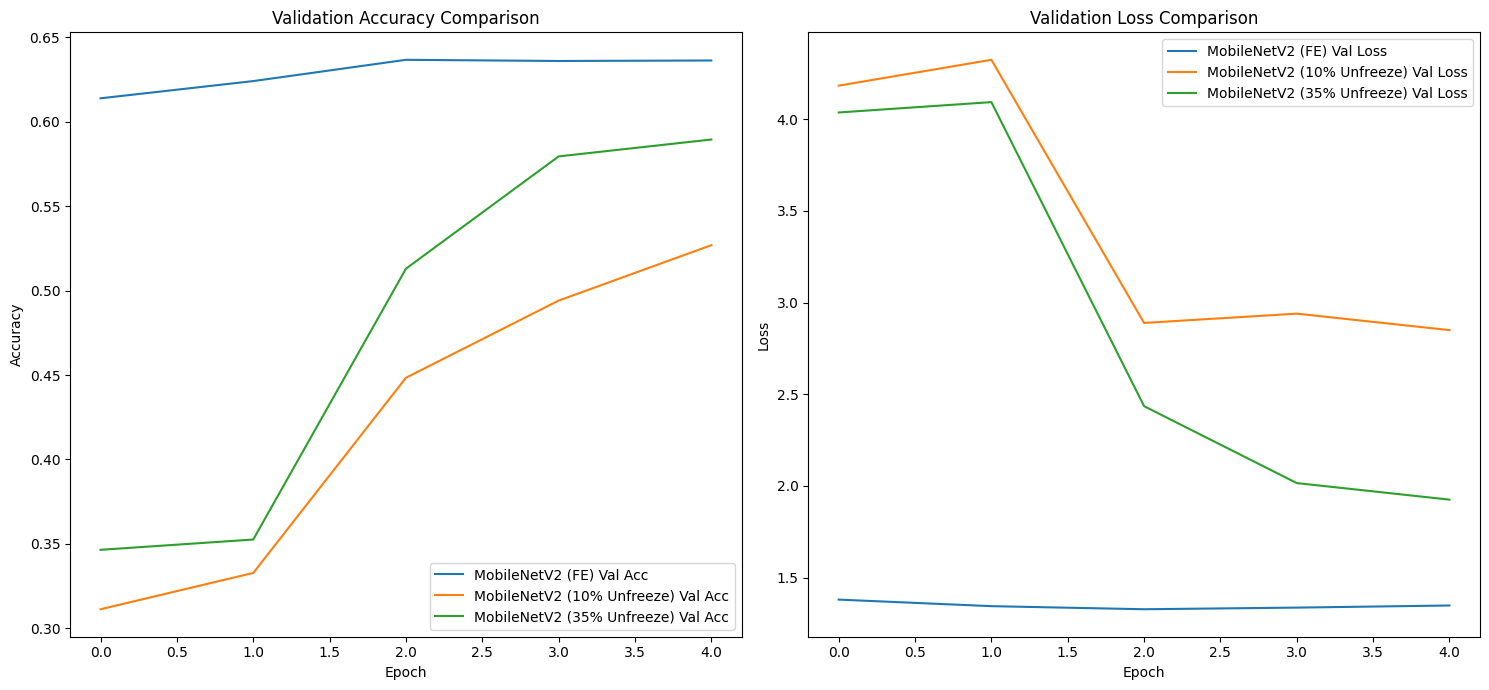

In [70]:
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.plot(results['MobileNetV2']['history'].history['val_accuracy'], label='MobileNetV2 (FE) Val Acc')
plt.plot(results['MobileNetV2_Unfreeze_10%']['history'].history['val_accuracy'], label='MobileNetV2 (10% Unfreeze) Val Acc')
plt.plot(results['MobileNetV2_Unfreeze_35%']['history'].history['val_accuracy'], label='MobileNetV2 (35% Unfreeze) Val Acc')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(results['MobileNetV2']['history'].history['val_loss'], label='MobileNetV2 (FE) Val Loss')
plt.plot(results['MobileNetV2_Unfreeze_10%']['history'].history['val_loss'], label='MobileNetV2 (10% Unfreeze) Val Loss')
plt.plot(results['MobileNetV2_Unfreeze_35%']['history'].history['val_loss'], label='MobileNetV2 (35% Unfreeze) Val Loss')
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## **Try Fine-Tuning Also With ResNet50V2**

### **Top 10% Unfreezing**

In [96]:
base_model_resnet_unfreeze_10 = keras.applications.ResNet50V2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

In [97]:
model_resnet_10 = build_model(base_model_resnet_unfreeze_10, NUM_CLASSES)

base_model_resnet_unfreeze_10.trainable = True
total_layers_resnet = len(base_model_resnet.layers)
unfreeze_percentage_10 = 0.10
freeze_until_10 = int(total_layers_resnet * (1.0 - unfreeze_percentage_10))

for layer in base_model_resnet_unfreeze_10.layers[:freeze_until_10]:
    layer.trainable = False

In [98]:
model_resnet_10.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_18 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_10 (Rescaling)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 4, 4, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_10     │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 100)            │       204,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,769,700 (90.67 MB)

 Trainable params: 8,084,580 (30.84 MB)

 Non-trainable params: 15,685,120 (59.83 MB)

In [78]:
history_resnet_10, train_time_resnet_10 = train_model(
    model_resnet_10, 
    'anything',
    train_ds, 
    test_ds, 
    BATCH_SIZE
)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4326 - loss: 2.2152

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 95s 51ms/step - accuracy: 0.5226 - loss: 1.7525 - val_accuracy: 0.6209 - val_loss: 1.3461 - learning_rate: 9.5000e-04
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6697 - loss: 1.1343

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.6929 - loss: 1.0368 - val_accuracy: 0.6432 - val_loss: 1.2971 - learning_rate: 9.0250e-04
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - accuracy: 0.7951 - loss: 0.6567 - val_accuracy: 0.6474 - val_loss: 1.4429 - learning_rate: 8.5737e-04
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - accuracy: 0.8701 - loss: 0.4014 - val_accuracy: 0.6508 - val_loss: 1.5697 - learning_rate: 8.1451e-04
anything Training Time: 298.29 seconds
anything Best Val Accuracy: 0.6508


#### **Results**

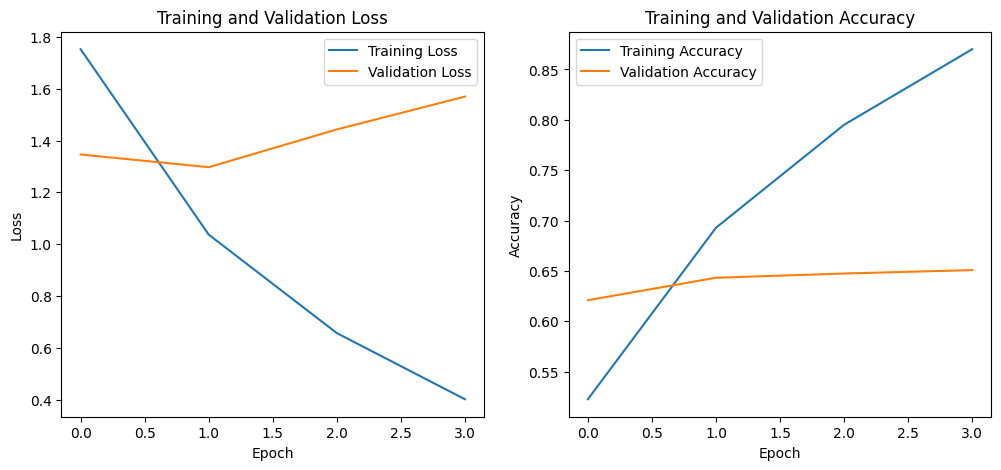

In [80]:
plot_loss_accuracy_comparison(history_resnet_10)


Confusion Matrix & Classification Report
----------------------------------------
               precision    recall  f1-score   support

        apple       0.81      0.76      0.78       100
aquarium_fish       0.70      0.76      0.73       100
         baby       0.58      0.45      0.51       100
         bear       0.38      0.49      0.43       100
       beaver       0.73      0.37      0.49       100
          bed       0.61      0.86      0.71       100
          bee       0.58      0.73      0.65       100
       beetle       0.64      0.54      0.58       100
      bicycle       0.91      0.82      0.86       100
       bottle       0.97      0.69      0.81       100
         bowl       0.65      0.47      0.55       100
          boy       0.35      0.64      0.46       100
       bridge       0.54      0.82      0.65       100
          bus       0.76      0.59      0.66       100
    butterfly       0.80      0.69      0.74       100
        camel       0.74      0.57  

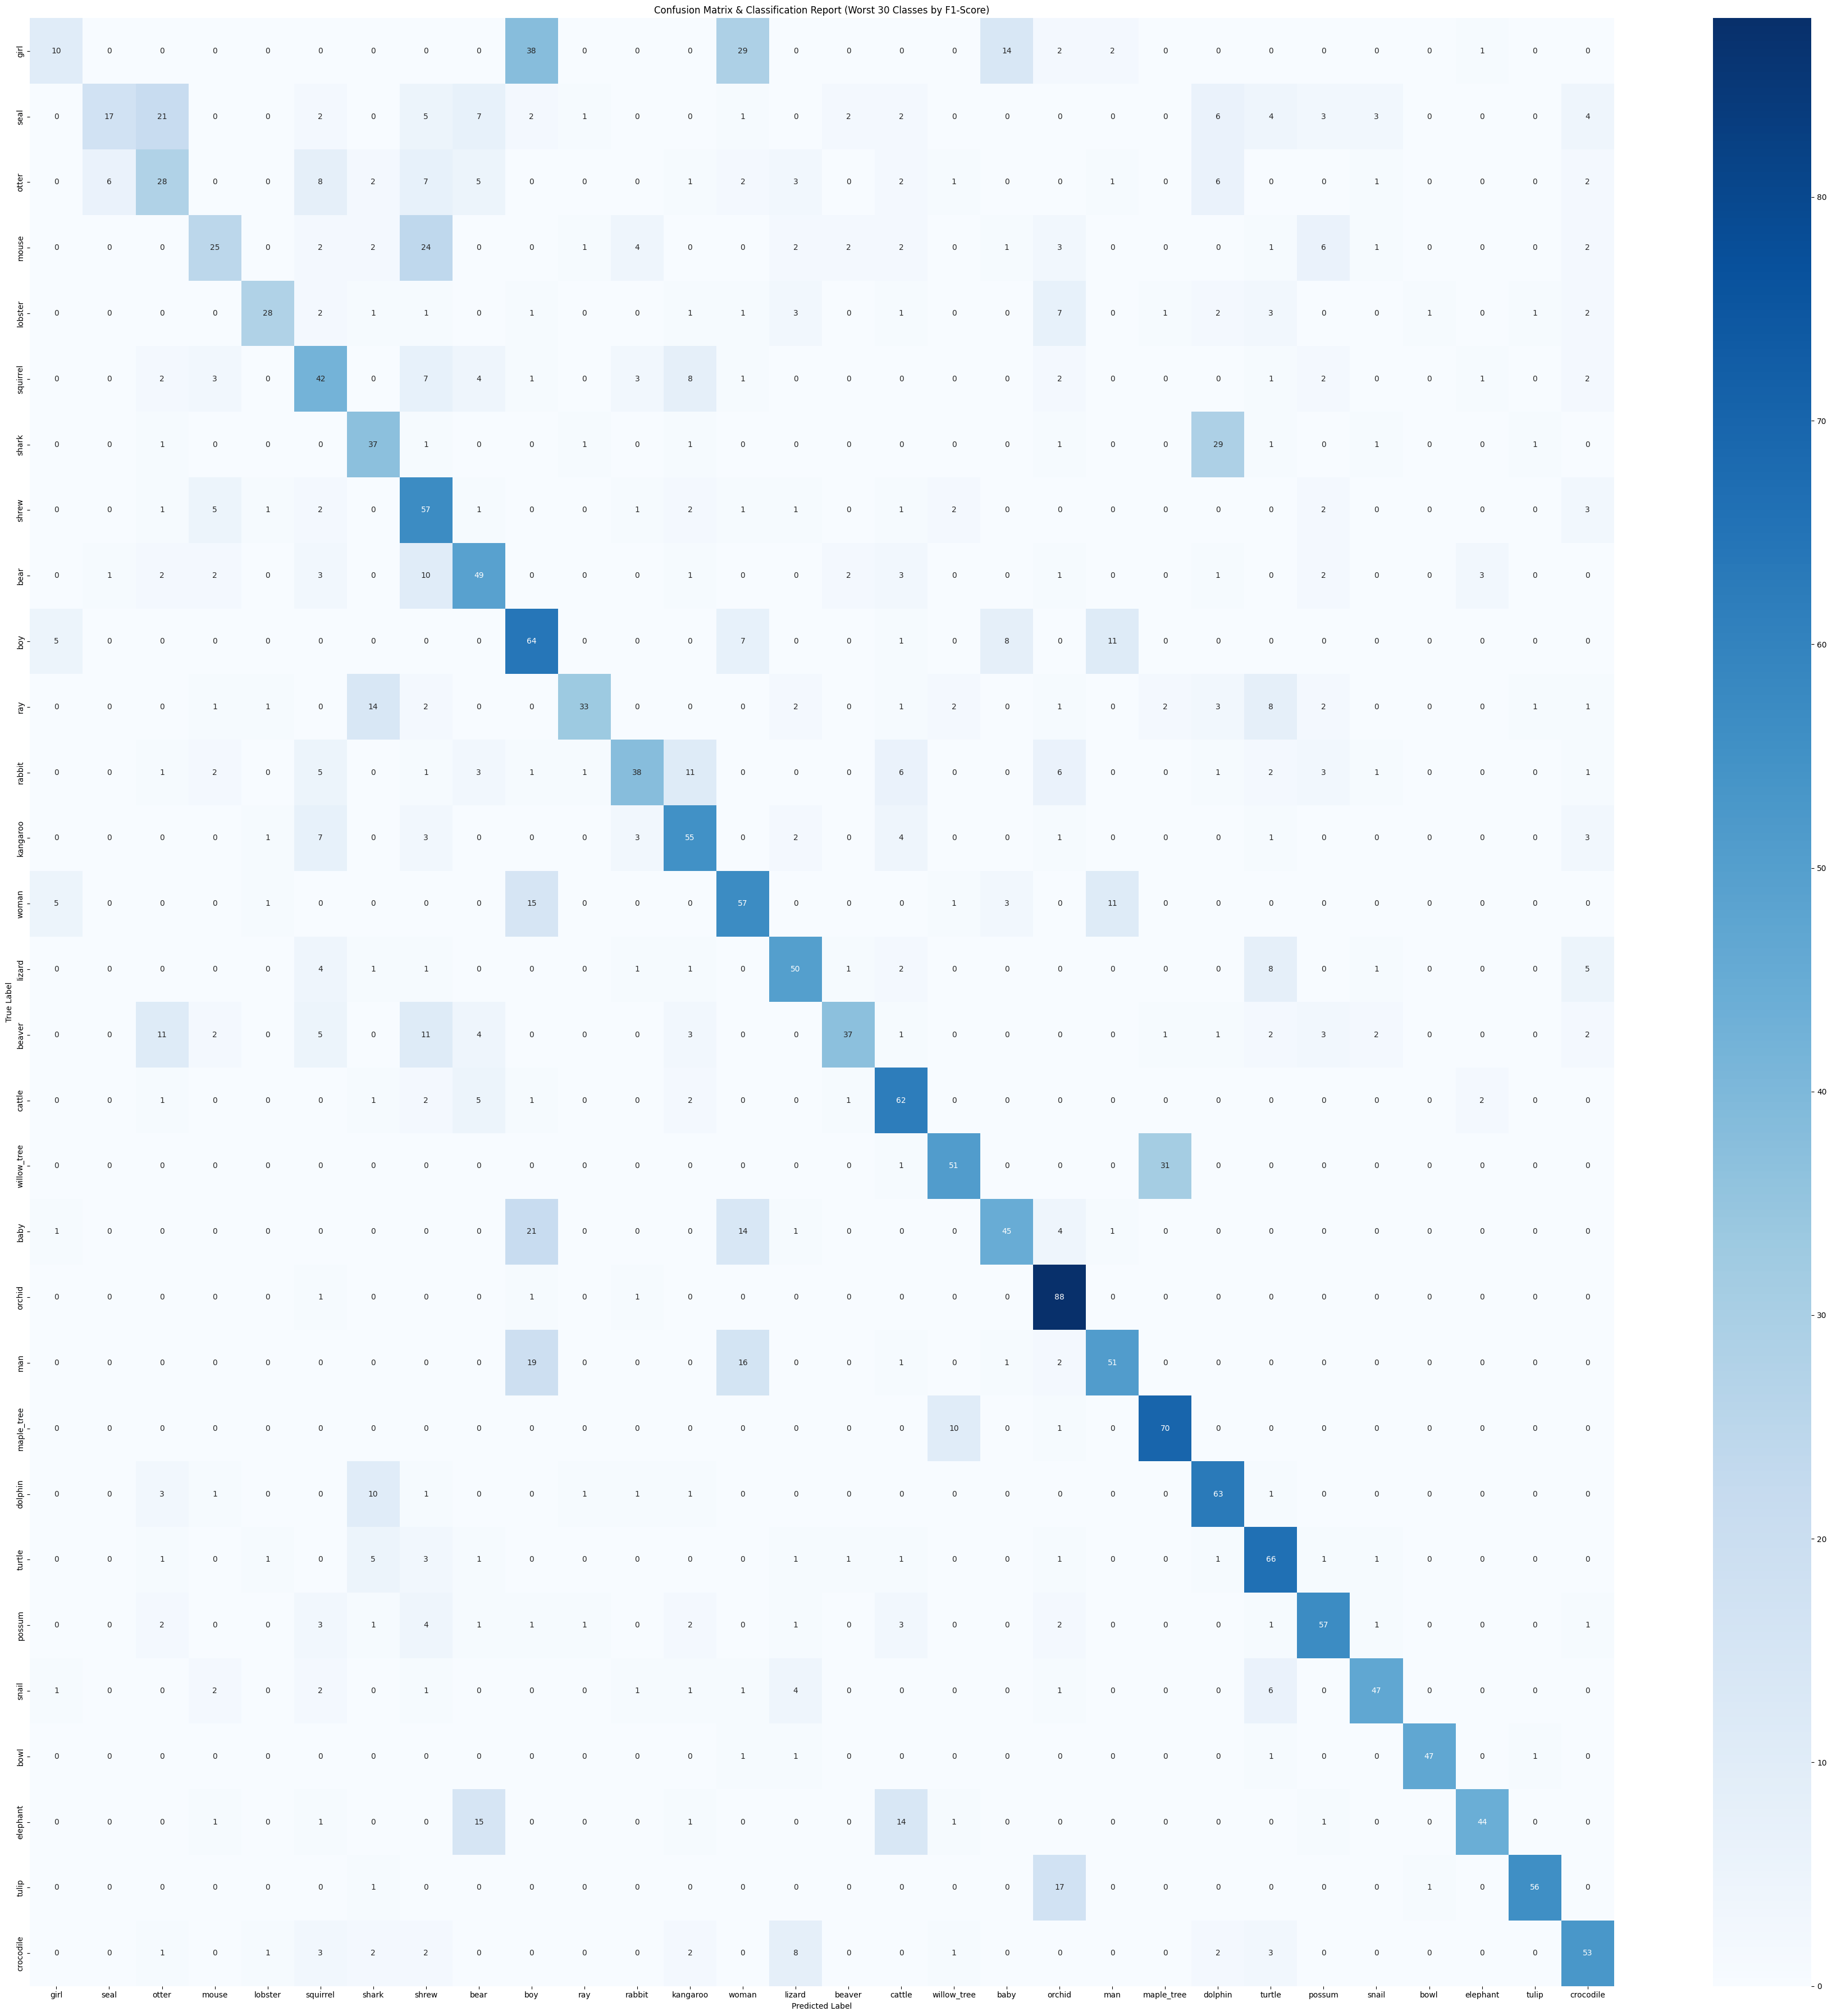

In [81]:
confusion_matrix_and_classification_report(model_resnet_10, test_ds,
                                           class_names=cifar100_fine_labels, display_confusion_for_worst_n_classes=30)

In [92]:
results['ResNet50V2_Unfreeze_10%'] = {
    'training_time': train_time_resnet_10,
    'val_accuracy': history_resnet_10.history['val_accuracy'][-1],
    'history': history_resnet_10
}

### **Deep 35% Unfreezing**

In [93]:
base_model_resnet_35 = keras.applications.ResNet50V2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

In [94]:
model_resnet_35 = build_model(base_model_resnet_unfreeze_35, NUM_CLASSES)

base_model_resnet_unfreeze_35.trainable = True

total_layers_res_net = len(base_model_resnet.layers)
unfreeze_percentage_35 = 0.10
freeze_until_35 = int(total_layers_res_net * (1.0 - unfreeze_percentage_35))

for layer in base_model_resnet_unfreeze_35.layers[:freeze_until_35]:
    layer.trainable = False

In [89]:
model_resnet_35.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_8 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 4, 4, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 100)            │       204,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,769,700 (90.67 MB)

 Trainable params: 8,084,580 (30.84 MB)

 Non-trainable params: 15,685,120 (59.83 MB)

In [90]:
history_resnet_35, train_time_resnet_35 = train_model(
    model_resnet_35, 
    'anything',
    train_ds, 
    test_ds, 
    BATCH_SIZE
)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4385 - loss: 2.1959

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 93s 51ms/step - accuracy: 0.5244 - loss: 1.7426 - val_accuracy: 0.6110 - val_loss: 1.3647 - learning_rate: 9.5000e-04
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6670 - loss: 1.1409

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.6931 - loss: 1.0370 - val_accuracy: 0.6464 - val_loss: 1.3282 - learning_rate: 9.0250e-04
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - accuracy: 0.7974 - loss: 0.6510 - val_accuracy: 0.6525 - val_loss: 1.4476 - learning_rate: 8.5737e-04
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 67s 43ms/step - accuracy: 0.8716 - loss: 0.3996 - val_accuracy: 0.6575 - val_loss: 1.5921 - learning_rate: 8.1451e-04
anything Training Time: 297.12 seconds
anything Best Val Accuracy: 0.6575


#### **Results**

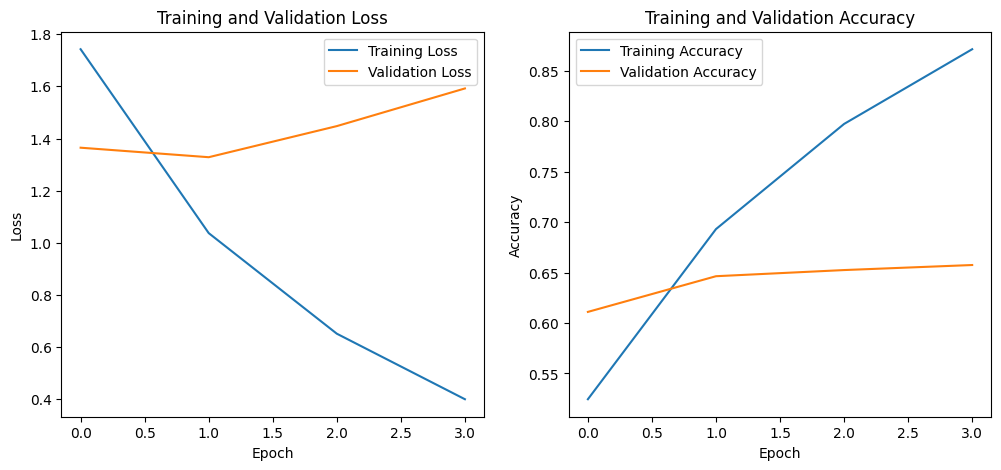

In [91]:
plot_loss_accuracy_comparison(history_resnet_35)


Confusion Matrix & Classification Report
----------------------------------------
               precision    recall  f1-score   support

        apple       0.00      0.00      0.00       100
aquarium_fish       0.06      0.04      0.05       100
         baby       0.00      0.00      0.00       100
         bear       0.00      0.00      0.00       100
       beaver       0.00      0.00      0.00       100
          bed       0.00      0.00      0.00       100
          bee       0.21      0.05      0.08       100
       beetle       0.00      0.00      0.00       100
      bicycle       0.00      0.00      0.00       100
       bottle       0.00      0.00      0.00       100
         bowl       0.00      0.00      0.00       100
          boy       0.00      0.00      0.00       100
       bridge       0.00      0.00      0.00       100
          bus       0.04      0.01      0.02       100
    butterfly       0.00      0.00      0.00       100
        camel       0.01      0.01  

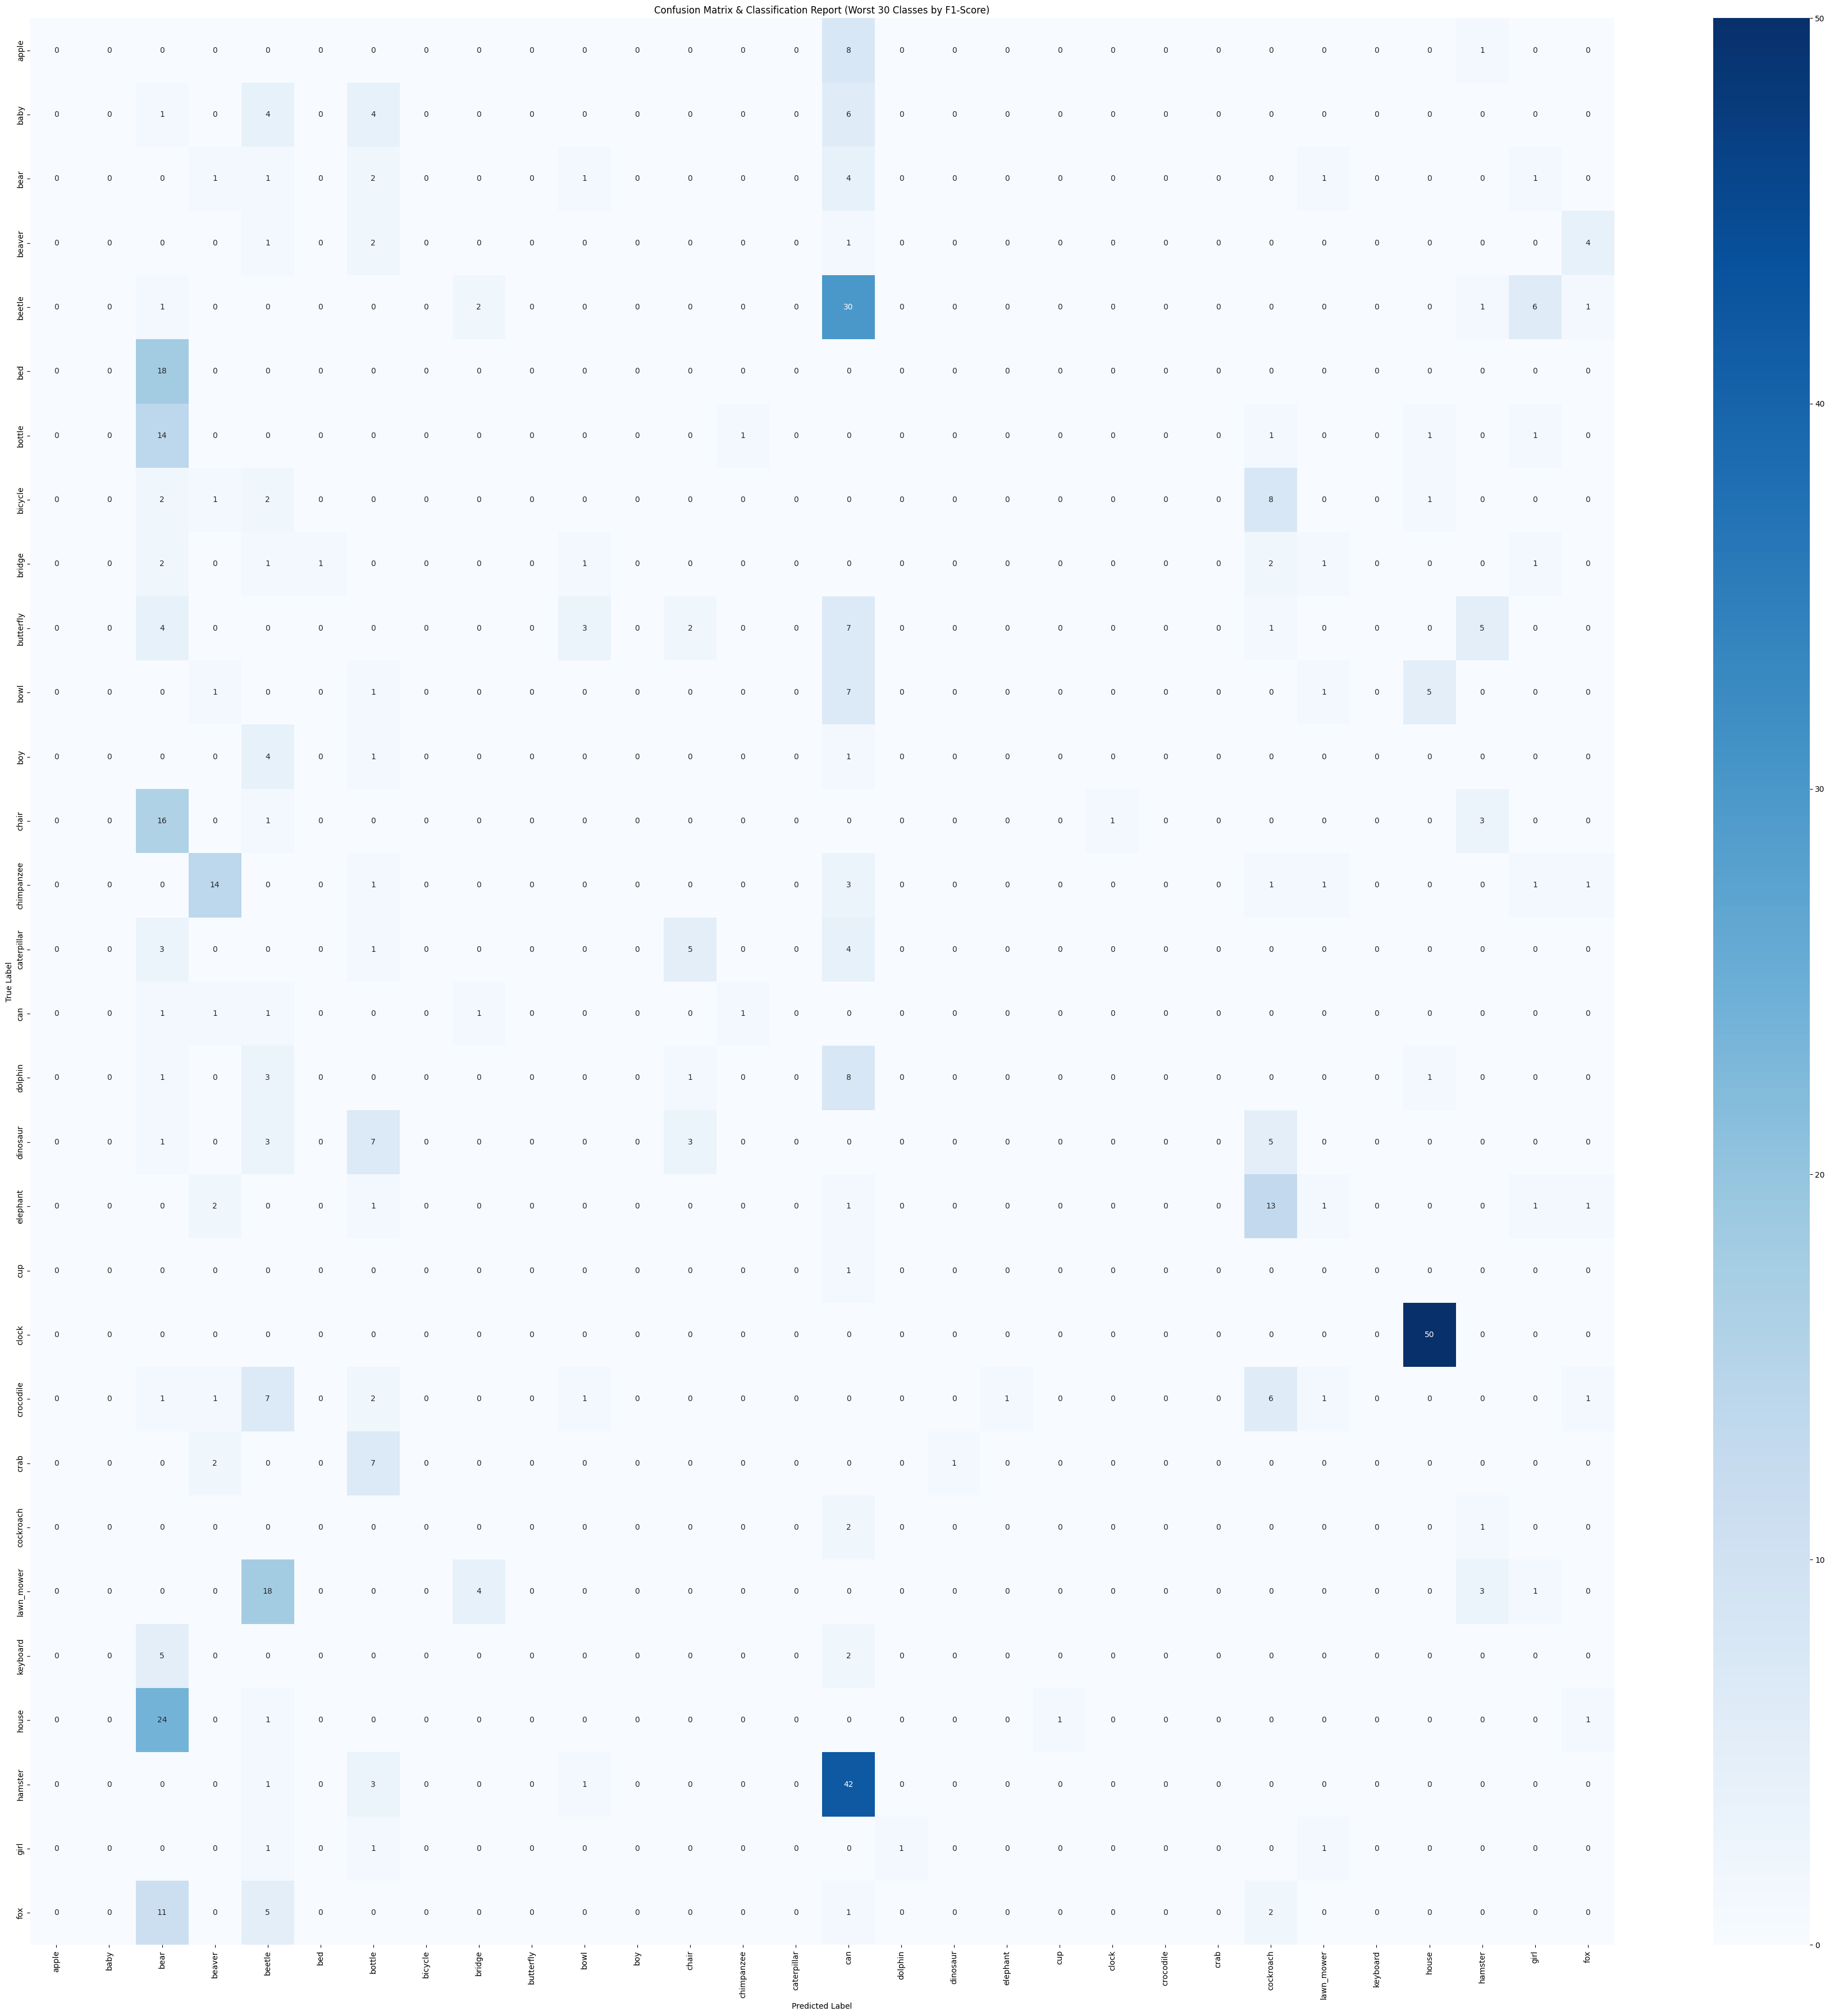

In [95]:
confusion_matrix_and_classification_report(model_resnet_35, test_ds,
                                           class_names=cifar100_fine_labels, display_confusion_for_worst_n_classes=30)

In [102]:
results['ResNet50V2_Unfreeze_35%'] = {
    'training_time': train_time_resnet_35,
    'val_accuracy': history_resnet_35.history['val_accuracy'][-1],
    'history': history_resnet_35
}

### **Comparison of Fine-Tuning Strategies**

In [103]:
for model_name, data in results.items():
    print(f"Model: {model_name}")
    print(f"  Training Time: {data['training_time']:.2f} seconds")
    print(f"  Validation Accuracy: {data['val_accuracy']:.4f}")
    print(f"  Effiency -> Accuracy / Seconds : {results[model_name]['val_accuracy'] / results[model_name]['training_time']}")

best_accuracy = max(results, key=lambda k: results[k]['val_accuracy'])

best_time = min(results, key=lambda k: results[k]['training_time'])

best_efficiency = max(results, key=lambda k: results[k]['val_accuracy'] / results[k]['training_time'])

print(f"\nBest by Accuracy: {best_accuracy} ({results[best_accuracy]['val_accuracy']:.4f})")
print(f"Best by Time: {best_time} ({results[best_time]['training_time']:.4f})")
print(f"Efficient (accuracy/sec): {best_efficiency} ({results[best_efficiency]['val_accuracy']/results[best_efficiency]['training_time']:.6f})")

Model: ResNet50V2
  Training Time: 221.81 seconds
  Validation Accuracy: 0.6054
  Effiency -> Accuracy / Seconds : 0.0027293734328354222
Model: MobileNetV2
  Training Time: 142.04 seconds
  Validation Accuracy: 0.6363
  Effiency -> Accuracy / Seconds : 0.00447970480792431
Model: MobileNetV2_Unfreeze_10%
  Training Time: 145.74 seconds
  Validation Accuracy: 0.5269
  Effiency -> Accuracy / Seconds : 0.00361545383506532
Model: MobileNetV2_Unfreeze_35%
  Training Time: 196.04 seconds
  Validation Accuracy: 0.5895
  Effiency -> Accuracy / Seconds : 0.003006964364364627
Model: ResNet50V2_Unfreeze_10%
  Training Time: 298.29 seconds
  Validation Accuracy: 0.6508
  Effiency -> Accuracy / Seconds : 0.002181744988520125
Model: ResNet50V2_Unfreeze_35%
  Training Time: 297.12 seconds
  Validation Accuracy: 0.6575
  Effiency -> Accuracy / Seconds : 0.0022129380714614334

Best by Accuracy: ResNet50V2_Unfreeze_35% (0.6575)
Best by Time: MobileNetV2 (142.0406)
Efficient (accuracy/sec): MobileNetV2 (0

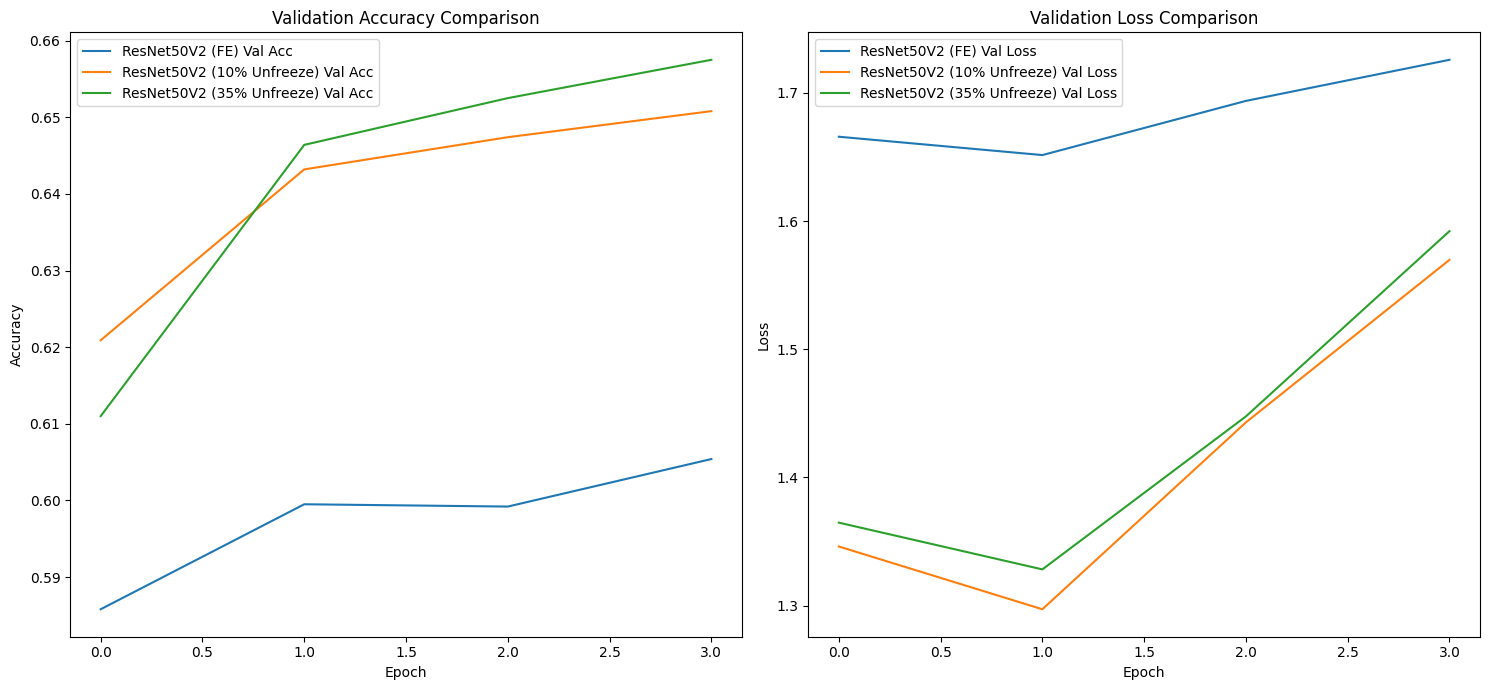

In [104]:
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.plot(results['ResNet50V2']['history'].history['val_accuracy'], label='ResNet50V2 (FE) Val Acc')
plt.plot(results['ResNet50V2_Unfreeze_10%']['history'].history['val_accuracy'], label='ResNet50V2 (10% Unfreeze) Val Acc')
plt.plot(results['ResNet50V2_Unfreeze_35%']['history'].history['val_accuracy'], label='ResNet50V2 (35% Unfreeze) Val Acc')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(results['ResNet50V2']['history'].history['val_loss'], label='ResNet50V2 (FE) Val Loss')
plt.plot(results['ResNet50V2_Unfreeze_10%']['history'].history['val_loss'], label='ResNet50V2 (10% Unfreeze) Val Loss')
plt.plot(results['ResNet50V2_Unfreeze_35%']['history'].history['val_loss'], label='ResNet50V2 (35% Unfreeze) Val Loss')
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()